<a href="https://colab.research.google.com/github/Llamalu1/day_99_space_missions_analysis/blob/main/Space_Missions_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [ ]:
%pip install iso3166

### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [ ]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 20.9 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


### Import Statements

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

### Notebook Presentation

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [ ]:
df_data = pd.read_csv('sample_data/mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`?
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [ ]:
print(f"Shape: {df_data.shape}")
print(f"\nNaN values per column:\n{df_data.isna().sum()}")

Shape: (4324, 9)

NaN values per column:
Unnamed: 0.1         0
Unnamed: 0           0
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64


In [ ]:
columns = df_data.shape[1]
rows = df_data.shape[0]
print(f"Columns = {columns} ")
print(f"Rows = {rows}")

Columns = 9 
Rows = 4324


In [ ]:
columns_nm = df_data.columns
print(f"Columns: {columns_nm} ")

Columns: Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object') 


In [ ]:

# Are there any duplicated values?
duplicated = df_data.duplicated().sum()
print(f"There are {duplicated} duplicated values")

There are 0 duplicated values


## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data.

In [ ]:
clean_df = df_data.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'])
clean_df.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


## Descriptive Statistics
Clean Price by removing the $ and coma's also convert to numeric

In [ ]:
clean_df['Price'] = (
    clean_df['Price']
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
)

clean_df['Price'] = pd.to_numeric(clean_df['Price'], errors='coerce')

Clean Date, convert it to pandas datetime from the format they are in, and if values can't be converted, convert to NaT(Not a Time) to avoid errors.




In [ ]:
clean_df['Date'] = pd.to_datetime(
    clean_df['Date'],
    utc=True,
    errors='coerce'
)

In [ ]:
# Extract time components
clean_df['Year']  = clean_df['Date'].dt.year.astype('Int64')  # Int64 handles NaN
clean_df['Month'] = clean_df['Date'].dt.month.astype('Int64')
clean_df['Day']   = clean_df['Date'].dt.day_name()



In [ ]:
# Clean Rocket_Status: remove 'Status' prefix
clean_df['Rocket_Status'] = clean_df['Rocket_Status'].str.replace('Status', '', regex=False)


In [ ]:
# Drop rows where Date failed to parse (can't analyze without a year)
clean_df = clean_df.dropna(subset=['Date'])

print(f"Clean shape: {clean_df.shape}")
print(f"\nNaN values after cleaning:\n{clean_df.isna().sum()}")
print(f"\nYear range: {clean_df['Year'].min()} - {clean_df['Year'].max()}")
print(f"Rocket_Status values: {clean_df['Rocket_Status'].unique()}")
print(f"Mission_Status values: {clean_df['Mission_Status'].unique()}")

Clean shape: (4198, 10)

NaN values after cleaning:
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3240
Mission_Status       0
Year                 0
Month                0
Day                  0
dtype: int64

Year range: 1957 - 2020
Rocket_Status values: ['Active' 'Retired']
Mission_Status values: ['Success' 'Failure' 'Partial Failure' 'Prelaunch Failure']


In [ ]:
print(clean_df.dtypes)
print(f"\nTotal missions: {len(clean_df)}")
print(f"Years present: {sorted(clean_df['Year'].dropna().unique())}")
clean_df.head()

Organisation                   object
Location                       object
Date              datetime64[ns, UTC]
Detail                         object
Rocket_Status                  object
Price                         float64
Mission_Status                 object
Year                            Int64
Month                           Int64
Day                            object
dtype: object

Total missions: 4198
Years present: [np.int64(1957), np.int64(1958), np.int64(1959), np.int64(1960), np.int64(1961), np.int64(1962), np.int64(1963), np.int64(1964), np.int64(1965), np.int64(1966), np.int64(1967), np.int64(1968), np.int64(1969), np.int64(1970), np.int64(1971), np.int64(1972), np.int64(1973), np.int64(1974), np.int64(1975), np.int64(1976), np.int64(1977), np.int64(1978), np.int64(1979), np.int64(1980), np.int64(1981), np.int64(1982), np.int64(1983), np.int64(1984), np.int64(1985), np.int64(1986), np.int64(1987), np.int64(1988), np.int64(1989), np.int64(1990), np.int64(1991), np.int64

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,Year,Month,Day
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA",2020-08-07 05:12:00+00:00,Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,Active,50.00,Success,2020,8,Friday
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...",2020-08-06 04:01:00+00:00,Long March 2D | Gaofen-9 04 & Q-SAT,Active,29.75,Success,2020,8,Thursday
2,SpaceX,"Pad A, Boca Chica, Texas, USA",2020-08-04 23:57:00+00:00,Starship Prototype | 150 Meter Hop,Active,NaN,Success,2020,8,Tuesday
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan",2020-07-30 21:25:00+00:00,Proton-M/Briz-M | Ekspress-80 & Ekspress-103,Active,65.00,Success,2020,7,Thursday
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA",2020-07-30 11:50:00+00:00,Atlas V 541 | Perseverance,Active,145.00,Success,2020,7,Thursday


# **Total launches **
Includes failed and successful

In [ ]:
print(f'Total Launches: {len(clean_df)}')

Total Launches: 4198


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

# **Total Launches Per Company**

In [ ]:
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 10
launch_counts = clean_df['Organisation'].value_counts()


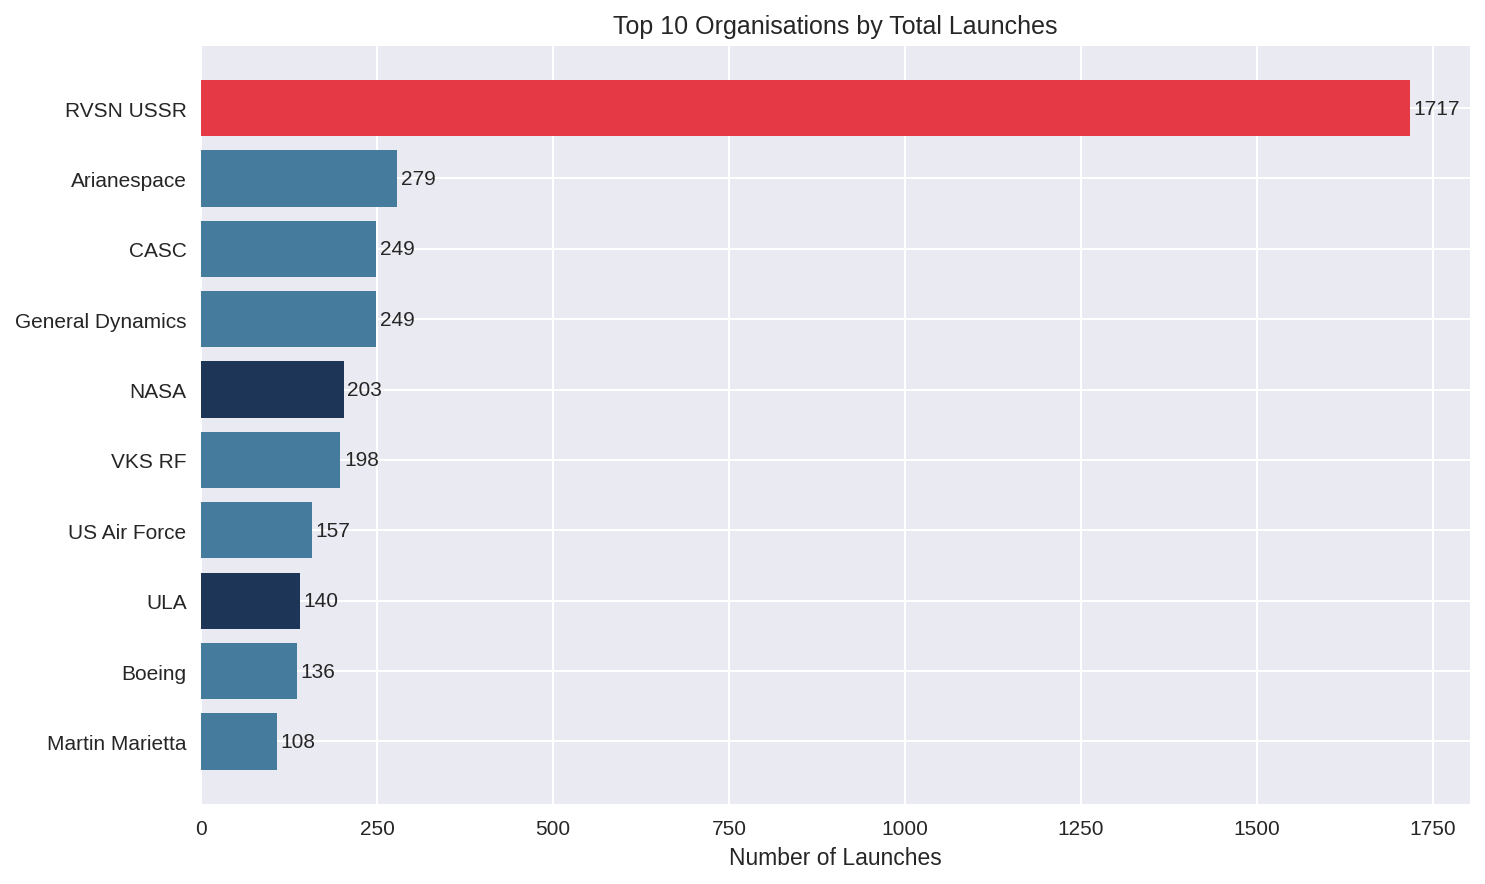


Total Launches: 4198
Total Organisations: 55

Top 10:
Organisation
RVSN USSR           1717
Arianespace          279
CASC                 249
General Dynamics     249
NASA                 203
VKS RF               198
US Air Force         157
ULA                  140
Boeing               136
Martin Marietta      108


In [ ]:


top10 = launch_counts.head(10)

# Color bars by country/org origin
colors = ['#e63946' if org in ['RVSN USSR', 'Roscosmos', 'MO USSR']
          else '#1d3557' if org in ['SpaceX', 'ULA', 'NASA']
          else '#457b9d' for org in top10.index]

plt.figure(figsize=(10,6))
bars = plt.barh(top10.index, top10.values, color=colors)

plt.xlabel('Number of Launches')
plt.title('Top 10 Organisations by Total Launches')

# Add numbers to bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5,                 # position slightly right of bar
             bar.get_y() + bar.get_height()/2,
             str(int(width)),
             va='center')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Print summary
print(f"\nTotal Launches: {len(clean_df)}")
print(f"Total Organisations: {clean_df['Organisation'].nunique()}")
print(f"\nTop 10:\n{top10.to_string()}")

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned?

In [ ]:
#  verify what values actually exist
print(clean_df['Rocket_Status'].unique())
print(clean_df['Rocket_Status'].value_counts())

['Active' 'Retired']
Rocket_Status
Retired    3432
Active      766
Name: count, dtype: int64


In [ ]:
active_count = (clean_df['Rocket_Status'] == 'Active').sum()
print(f'There are {active_count} active rockets')

There are 766 active rockets


In [ ]:
retired_count= (clean_df['Rocket_Status'] == 'Retired').sum()
print(f'There are {retired_count} decomissioned rockets')

There are 3432 decomissioned rockets


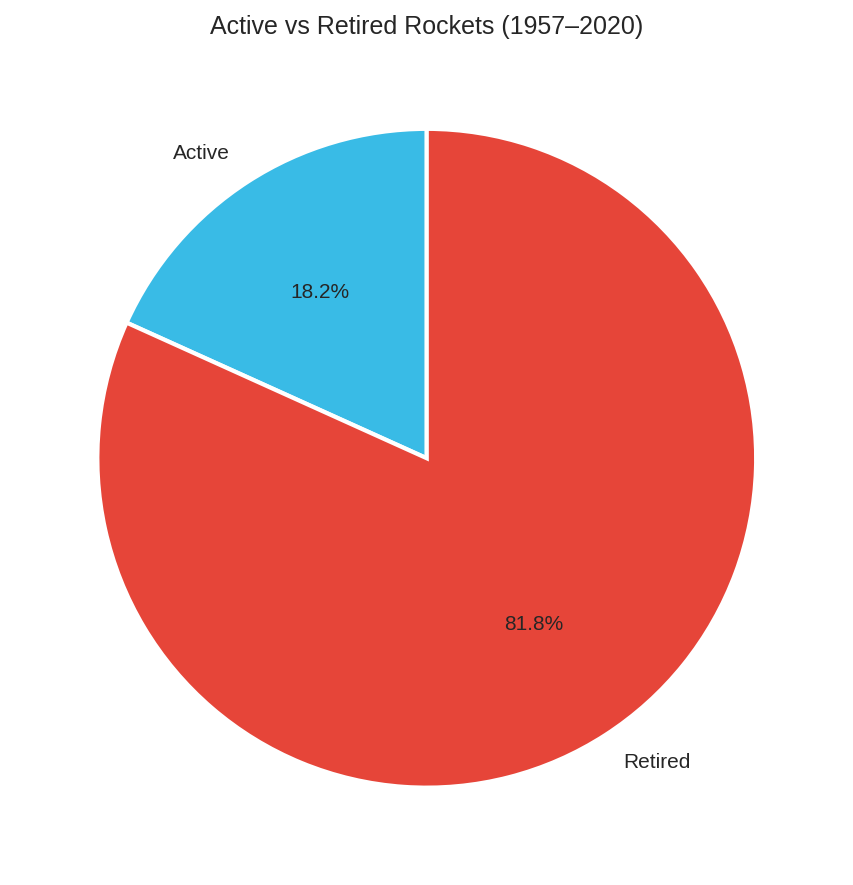

In [ ]:
plt.figure(figsize=(6, 6))
plt.pie(
    [active_count, retired_count],
    labels=['Active', 'Retired'],
    colors=['#39bbe6', '#e64539'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
plt.title('Active vs Retired Rockets (1957–2020)')
plt.tight_layout()
plt.show()

# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [ ]:
success_count = (clean_df['Mission_Status'] == 'Success').sum()
print(f' {success_count} Missions were successful')

 3794 Missions were successful


In [ ]:
failed_count = (clean_df['Mission_Status'] != 'Success').sum()
print(f' {failed_count} Missions failed')

 404 Missions failed


In [ ]:
status_counts = clean_df['Mission_Status'].value_counts()
print(f'Status count: {status_counts}')

success_count = (clean_df['Mission_Status'] == 'Success').sum()
print(f' {success_count} Missions were successful')

failed_count = (clean_df['Mission_Status'] != 'Success').sum()
print(f' {failed_count} Missions failed')

Status count: Mission_Status
Success              3794
Failure               300
Partial Failure       102
Prelaunch Failure       2
Name: count, dtype: int64
 3794 Missions were successful
 404 Missions failed


# A Different Way, more professional

In [ ]:
status_counts = clean_df['Mission_Status'].value_counts()
print(f'Status breakdown:\n{status_counts}\n')

success_count = status_counts.get('Success', 0)
total_missions = len(clean_df)
failed_count = total_missions - success_count

print(f'{success_count} Missions were successful')
print(f'{failed_count} Missions were not successful')

success_rate = (success_count / total_missions) * 100
failure_rate = 100 - success_rate

print(f'Success Rate: {success_rate:.2f}%')
print(f'Failure Rate: {failure_rate:.2f}%')


Status breakdown:
Mission_Status
Success              3794
Failure               300
Partial Failure       102
Prelaunch Failure       2
Name: count, dtype: int64

3794 Missions were successful
404 Missions were not successful
Success Rate: 90.38%
Failure Rate: 9.62%


# **Success Rate**

In [ ]:
success_rate = (clean_df['Mission_Status'] == 'Success').mean() * 100
print(f'Success Rate: {success_rate:.2f}%')

Success Rate: 90.38%


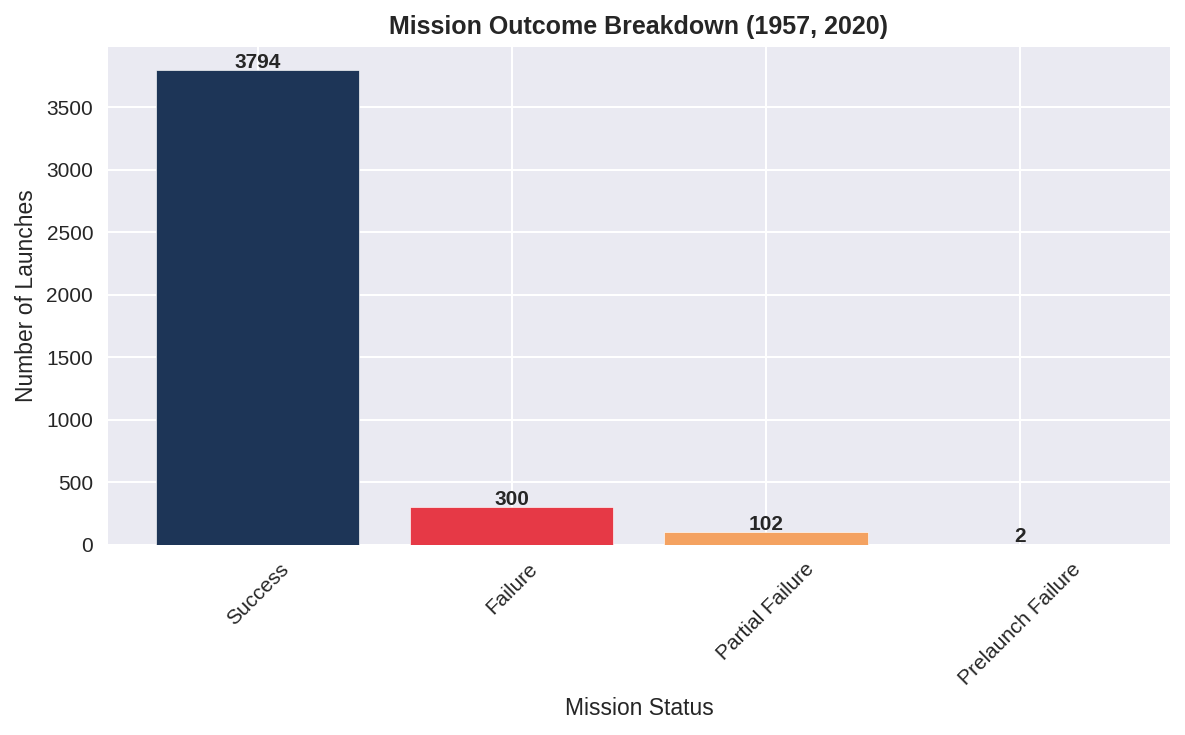

In [ ]:
import matplotlib.pyplot as plt

status_counts = clean_df['Mission_Status'].value_counts()

color_map = {
    'Success':           '#1d3557',
    'Failure':           '#e63946',
    'Partial Failure':   '#f4a261',
    'Prelaunch Failure': '#e76f51'
}

colors = [color_map.get(s, '#adb5bd') for s in status_counts.index]

plt.figure(figsize=(8,5))
bars = plt.bar(status_counts.index, status_counts.values, color=colors, edgecolor='white')

plt.xlabel('Mission Status')
plt.ylabel('Number of Launches')
plt.title('Mission Outcome Breakdown (1957, 2020)', fontweight='bold')

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 20,
             str(int(height)),
             ha='center', fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

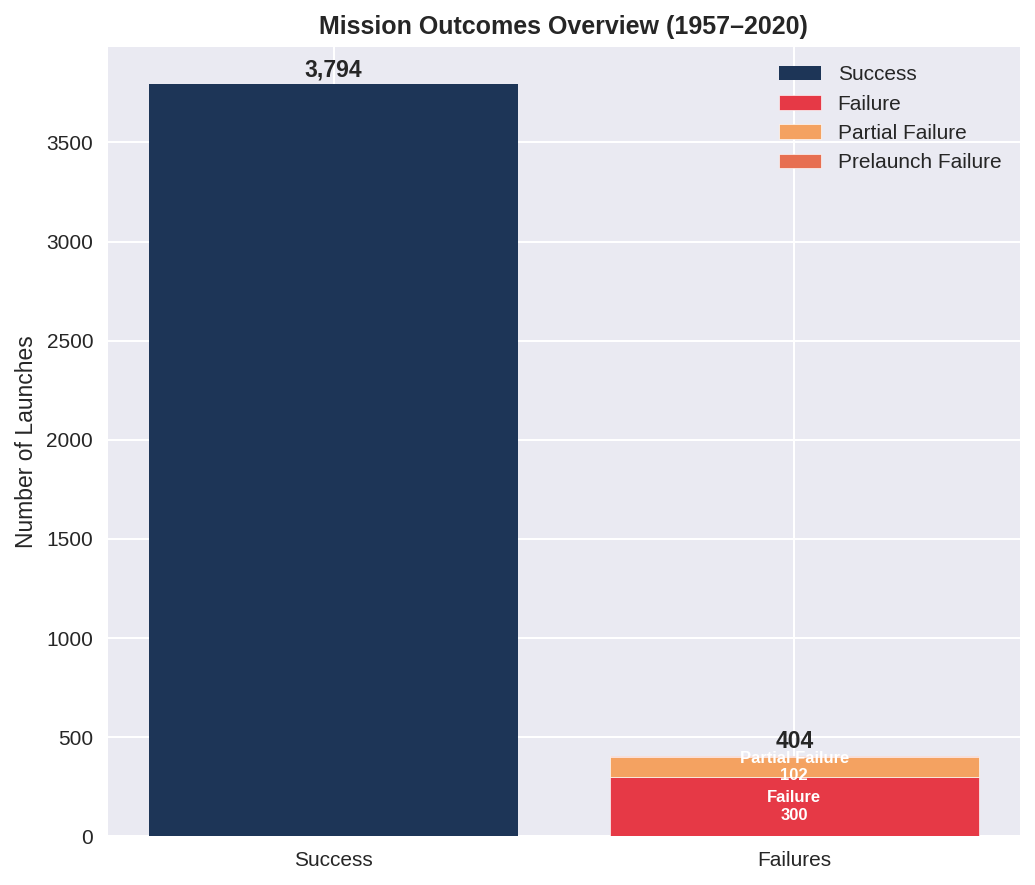


Success rate: 90.4%
Failure rate: 9.6%


In [ ]:
success = status_counts.get('Success', 0)
failures = status_counts.drop('Success', errors='ignore')

color_map = {
    'Failure':           '#e63946',
    'Partial Failure':   '#f4a261',
    'Prelaunch Failure': '#e76f51'
}

fig, ax = plt.subplots(figsize=(7, 6))

# Plot Success bar
ax.bar('Success', success, color='#1d3557', label='Success')

# Plot stacked failures
bottom = 0
for status, count in failures.items():
    ax.bar('Failures', count, bottom=bottom,
           color=color_map.get(status, '#adb5bd'),
           label=status, edgecolor='white')

    # Label each failure segment if big enough
    if count > 30:
        ax.text(1, bottom + count/2, f'{status}\n{count}',
                ha='center', va='center',
                fontsize=8, fontweight='bold', color='white')
    bottom += count

# Total labels on top of each bar
ax.text(0, success + 40, f'{success:,}', ha='center', fontweight='bold', fontsize=11)
ax.text(1, bottom + 40, f'{bottom:,}', ha='center', fontweight='bold', fontsize=11)

ax.set_ylabel('Number of Launches')
ax.set_title('Mission Outcomes Overview (1957–2020)', fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"\nSuccess rate: {success/len(clean_df)*100:.1f}%")
print(f"Failure rate: {bottom/len(clean_df)*100:.1f}%")

# How Expensive are the Launches?

Create a histogram and visualize the distribution. The price column is given in USD millions (careful of missing values).

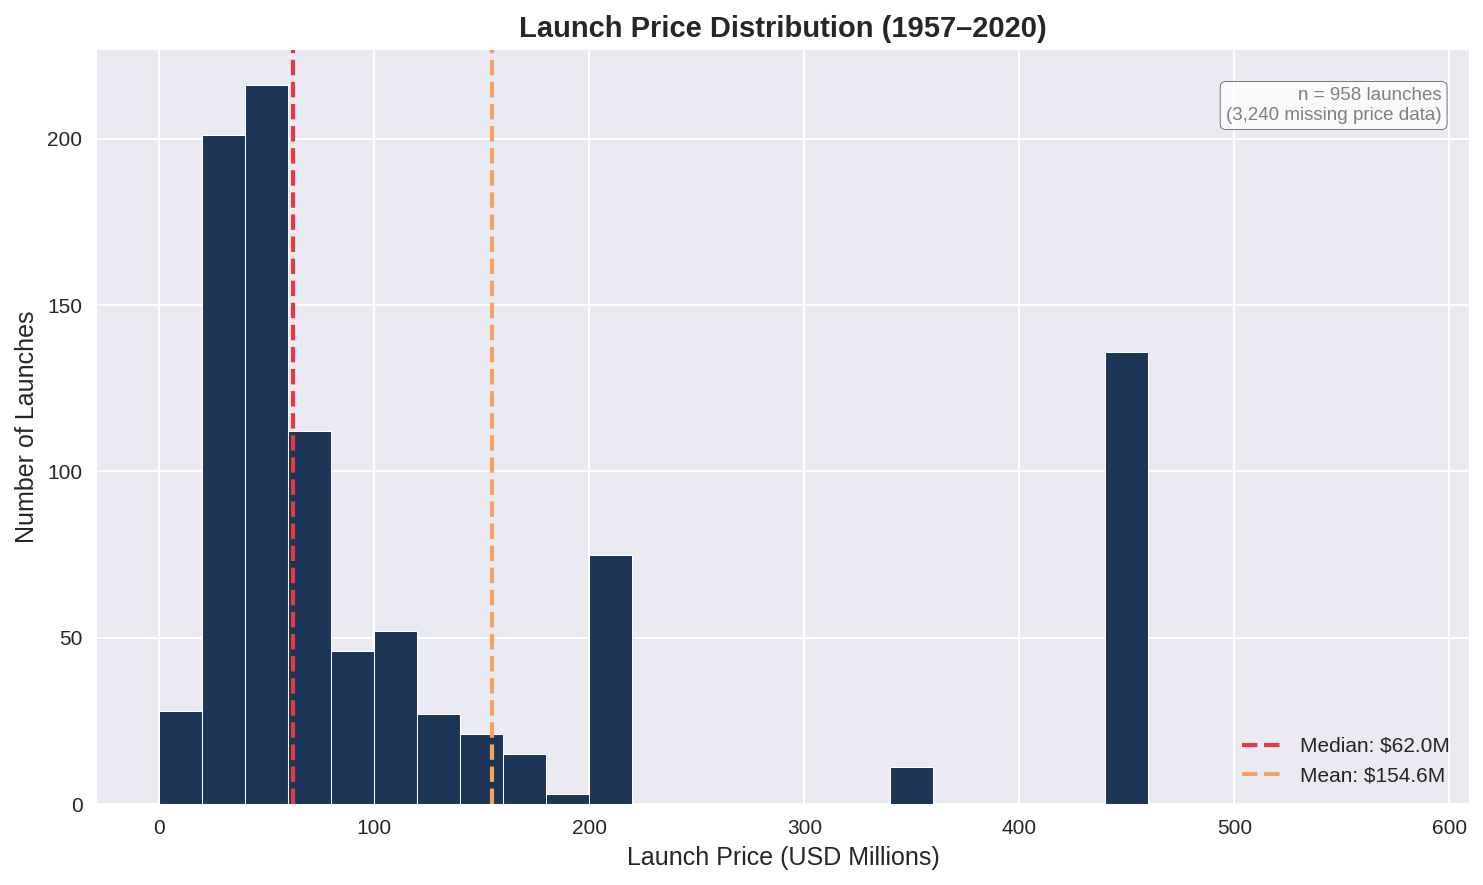

Price Statistics (USD Millions):
  Median : $62.0M
  Mean   : $154.6M
  Min    : $5.3M
  Max    : $5000.0M
  Launches with price data : 958
  Launches missing price   : 3,240


In [ ]:
import matplotlib.pyplot as plt

price_data = clean_df['Price'].dropna()
bins = np.arange(0, 600, 20)

fig, ax = plt.subplots(figsize=(10, 6))

n, bins_out, patches = ax.hist(price_data, bins=bins,
                                color='#1d3557', edgecolor='white', linewidth=0.5)

# Highlight the median
median_price = price_data.median()
mean_price = price_data.mean()

ax.axvline(median_price, color='#e63946', linestyle='--', linewidth=2, label=f'Median: ${median_price:.1f}M')
ax.axvline(mean_price,   color='#f4a261', linestyle='--', linewidth=2, label=f'Mean: ${mean_price:.1f}M')

ax.set_xlabel('Launch Price (USD Millions)', fontsize=12)
ax.set_ylabel('Number of Launches', fontsize=12)
ax.set_title('Launch Price Distribution (1957–2020)', fontweight='bold', fontsize=14)

# Add note about missing data
ax.text(0.98, 0.95,
        f'n = {len(price_data):,} launches\n({len(clean_df)-len(price_data):,} missing price data)',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=9, color='gray',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"Price Statistics (USD Millions):")
print(f"  Median : ${median_price:.1f}M")
print(f"  Mean   : ${mean_price:.1f}M")
print(f"  Min    : ${price_data.min():.1f}M")
print(f"  Max    : ${price_data.max():.1f}M")
print(f"  Launches with price data : {len(price_data):,}")
print(f"  Launches missing price   : {len(clean_df)-len(price_data):,}")

# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map.
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [ ]:
pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 50.2 MB/s eta 0:00:00


In [ ]:
launch_counts = clean_df['Location'].value_counts().reset_index()
launch_counts.columns = ['country', 'launch_count']

# Create ISO country names

In [ ]:
import pycountry

def country_to_iso(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except:
        return None

launch_counts['iso_alpha'] = launch_counts['country'].apply(country_to_iso)

In [ ]:
launch_counts.columns # check the ISO column has been created

Index(['country', 'launch_count', 'iso_alpha'], dtype='object')

In [ ]:
launch_counts['country'] = launch_counts['country'].str.split(',').str[-1].str.strip()

In [ ]:
launch_counts.head()

,country,launch_count,iso_alpha
0,Kazakhstan,224,None
1,Russia,208,None
2,Russia,202,None
3,Russia,198,None
4,Kazakhstan,190,None


In [ ]:
# Update country names
launch_counts['country'] = launch_counts['country'].replace({
    "Russia": "Russian Federation",
    "USA": "United States",
    "Pacific Ocean": "United States",
    "New Mexico": "United States",
    "Gran Canaria": "United States",
    "Shahrud Missile Test Site": "Iran",
    "Pacific Missile Range Facility": "United States",
    "Barents Sea": "Russian Federation",
    "Yellow Sea": "China",
    "South Korea": "Korea, Republic of",
    "North Korea": "Korea, Democratic People's Republic of"
})

In [ ]:
launch_counts = launch_counts.groupby('country', as_index=False)['launch_count'].sum()

In [ ]:
print(launch_counts)

                                   country  launch_count
0                                Australia             5
1                                   Brazil             1
2                                    China           265
3                                   France           303
4                                    India            75
5                                     Iran             3
6                                   Israel             2
7                                    Japan           122
8                               Kazakhstan           679
9                                    Kenya             9
10  Korea, Democratic People's Republic of             5
11                      Korea, Republic of             3
12                             New Zealand            13
13                      Russian Federation          1354
14                           United States          1359


In [ ]:
import pycountry

def country_to_iso(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except:
        return None

launch_counts['iso_alpha'] = launch_counts['country'].apply(country_to_iso)

In [ ]:
launch_counts.head()

,country,launch_count,iso_alpha
0,Australia,5,AUS
1,Brazil,1,BRA
2,China,265,CHN
3,France,303,FRA
4,India,75,IND


In [ ]:
# Check which countries failed to get an ISO code
missing = launch_counts[launch_counts['iso_alpha'].isna()]
print(f"Countries without ISO code:\n{missing[['country', 'launch_count']]}")

Countries without ISO code:
Empty DataFrame
Columns: [country, launch_count]
Index: []


In [ ]:
import plotly.express as px

fig = px.choropleth(
    launch_counts.dropna(subset=['iso_alpha']),
    locations="iso_alpha",
    color="launch_count",
    hover_name="country",
    color_continuous_scale=px.colors.sequential.Viridis_r,
    title="Number of Space Launches by Country"
)

fig.update_layout(
    title_font_size=16,
    title_x=0.5,
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth'
    ),
    coloraxis_colorbar=dict(title="Launches")
)


fig.show()

In [ ]:
columns_nm = clean_df.columns
print(f"Columns: {columns_nm} ")

Columns: Index(['Organisation', 'Location', 'Date', 'Detail', 'Rocket_Status', 'Price',
       'Mission_Status', 'Year', 'Month', 'Day'],
      dtype='object') 


## Stats by  Country
(Adding new columns for total Launches, succesful Launches and failed launches)

In [ ]:
clean_df['country'] = clean_df['Location'].str.split(',').str[-1].str.strip()

clean_df['country'] = clean_df['country'].replace({
    "Russia": "Russian Federation",
    "Pacific Ocean": "United States",
    "USA": "United States",
    "New Mexico": "United States",
    "Gran Canaria": "United States",
    "Shahrud Missile Test Site": "Iran",
    "Pacific Missile Range Facility": "United States",
    "Barents Sea": "Russian Federation",
    "Yellow Sea": "China",
    "South Korea": "Korea, Republic of",
    "North Korea": "Korea, Democratic People's Republic of",
    "Democratic People's Republic of": "Korea, Democratic People's Republic of",
    "Republic of Korea": "Korea, Republic of",
 })

**Create launch Statistics per Country**

In [ ]:
launch_stats = clean_df.groupby(['country','Mission_Status']).size().unstack(fill_value=0)


**Create Useful Columns (Total Launches, Successful, Failed...**

In [ ]:
launch_stats['total_launches'] = launch_stats.sum(axis=1)

launch_stats['failed_launches'] = (
    launch_stats['Failure'] +
    launch_stats['Partial Failure'] +
    launch_stats['Prelaunch Failure']
)

launch_stats = launch_stats.reset_index()

**Add ISO Codes**

In [ ]:
import pycountry

def country_to_iso(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except:
        return None

launch_stats['iso_alpha'] = launch_stats['country'].apply(country_to_iso)

In [ ]:
launch_stats.head()

Mission_Status,country,Failure,Partial Failure,Prelaunch Failure,Success,total_launches,failed_launches,iso_alpha
0,Australia,3,0,0,2,5,3,AUS
1,Brazil,1,0,0,0,1,1,BRA
2,China,16,6,0,243,265,22,CHN
3,France,13,5,0,285,303,18,FRA
4,India,8,5,0,62,75,13,IND


In [ ]:
# Verify no missing ISO codes
missing = launch_stats[launch_stats['iso_alpha'].isna()]
print(f"Missing ISO codes:\n{missing[['country', 'total_launches']]}")

Missing ISO codes:
Empty DataFrame
Columns: [country, total_launches]
Index: []


# Total Launches Map

In [ ]:
fig = px.choropleth(
    launch_stats,
    locations="iso_alpha",
    color="total_launches",
    hover_name="country",
    color_continuous_scale=px.colors.sequential.Viridis
)

fig.show()

# Use a Choropleth Map to Show the Number of Succesful launches by Country

In [ ]:
fig = px.choropleth(
    launch_stats,
    locations="iso_alpha",
    color="Success",
    hover_name="country",
    color_continuous_scale=px.colors.sequential.Viridis
)

fig.show()

# Use a Choropleth Map to Show the Number of Failures by Country


In [ ]:
fig = px.choropleth(
    launch_stats,
    locations="iso_alpha",
    color="failed_launches",
    hover_name="country",
    color_continuous_scale=px.colors.sequential.Viridis
)

fig.show()

**Adding Success Rate column:**

In [ ]:
launch_stats['success_rate'] = ((launch_stats['Success'] / launch_stats['total_launches']) * 100).round(2)


In [ ]:
launch_stats.columns # confirm new column was added

Index(['country', 'Failure', 'Partial Failure', 'Prelaunch Failure', 'Success',
       'total_launches', 'failed_launches', 'iso_alpha', 'success_rate'],
      dtype='object', name='Mission_Status')

In [ ]:
import plotly.graph_objects as go

# Custom hover text
launch_stats['hover_text'] = (
    '<b>' + launch_stats['country'] + '</b><br>' +
    'Total Launches: '    + launch_stats['total_launches'].astype(str) + '<br>' +
    'Successful: '        + launch_stats['Success'].astype(str) + '<br>' +
    'Failed: '            + launch_stats['failed_launches'].astype(str) + '<br>' +
    'Success Rate: '      + launch_stats['success_rate'].astype(str) + '%'
)
fig = go.Figure()

fig.add_trace(go.Choropleth(
    locations=launch_stats['iso_alpha'],
    z=launch_stats['total_launches'],
    text=launch_stats['hover_text'],
    hoverinfo='text',
    colorscale='Viridis',
    colorbar_title='Launches',
    marker_line_color='white',
    marker_line_width=0.5
    ))

fig.update_layout(
    title="Space Launches by Country",
    geo=dict(showframe=False, showcoastlines=True),
    updatemenus=[
        dict(
            buttons=[
                dict(
                    label="Total Launches",
                    method="update",
                    args=[{"z":[launch_stats['total_launches']]}]
                ),
                dict(
                    label="Successful Launches",
                    method="update",
                    args=[{"z":[launch_stats['Success']]}]
                ),
                dict(
                    label="Failed Launches",
                    method="update",
                    args=[{"z":[launch_stats['failed_launches']]}]
                ),
                dict(
                    label="Success Rate",
                    method="update",
                    args=[{"z":[launch_stats['success_rate']]}]
                )
            ],
            direction="down",
            showactive=True,
        )
    ]
)

fig.show()

# Create a Plotly Sunburst Chart of the countries, organizations, and mission status.

In [ ]:
import plotly.express as px

fig = px.sunburst(
    clean_df,
    path=['country', 'Organisation', 'Mission_Status'],
    title="Space Missions by Country, Organisation, and Mission Status",

)
fig.update_layout(
    title_x=0.5,
    title_font_size=16,
    width=800,
    height=800
)

fig.show()

# Analyse the Total Amount of Money Spent by Organization on Space Missions

In [ ]:
clean_df['Price'].isna().sum() # number of data rows without coast data!! Lots!!!

np.int64(3240)

In [ ]:
org_spending = clean_df.groupby('Organisation')['Price'].sum().reset_index()
org_spending = org_spending.sort_values(by='Price', ascending=False)
top10_spending = org_spending.head(10)
# print(top10_spending)

In [ ]:
print(f"Total known spending: ${org_spending['Price'].sum():,.1f}M")
print(f"Missing price data: {clean_df['Price'].isna().sum()} launches\n")
print(top10_spending.to_string(index=False))

Total known spending: $148,087.4M
Missing price data: 3240 launches

Organisation     Price
        NASA 76,280.00
 Arianespace 16,345.00
         ULA 14,798.00
   RVSN USSR 10,000.00
        CASC  6,334.96
      SpaceX  5,444.00
    Northrop  3,930.00
         MHI  3,532.50
        ISRO  2,146.00
      VKS RF  1,548.90


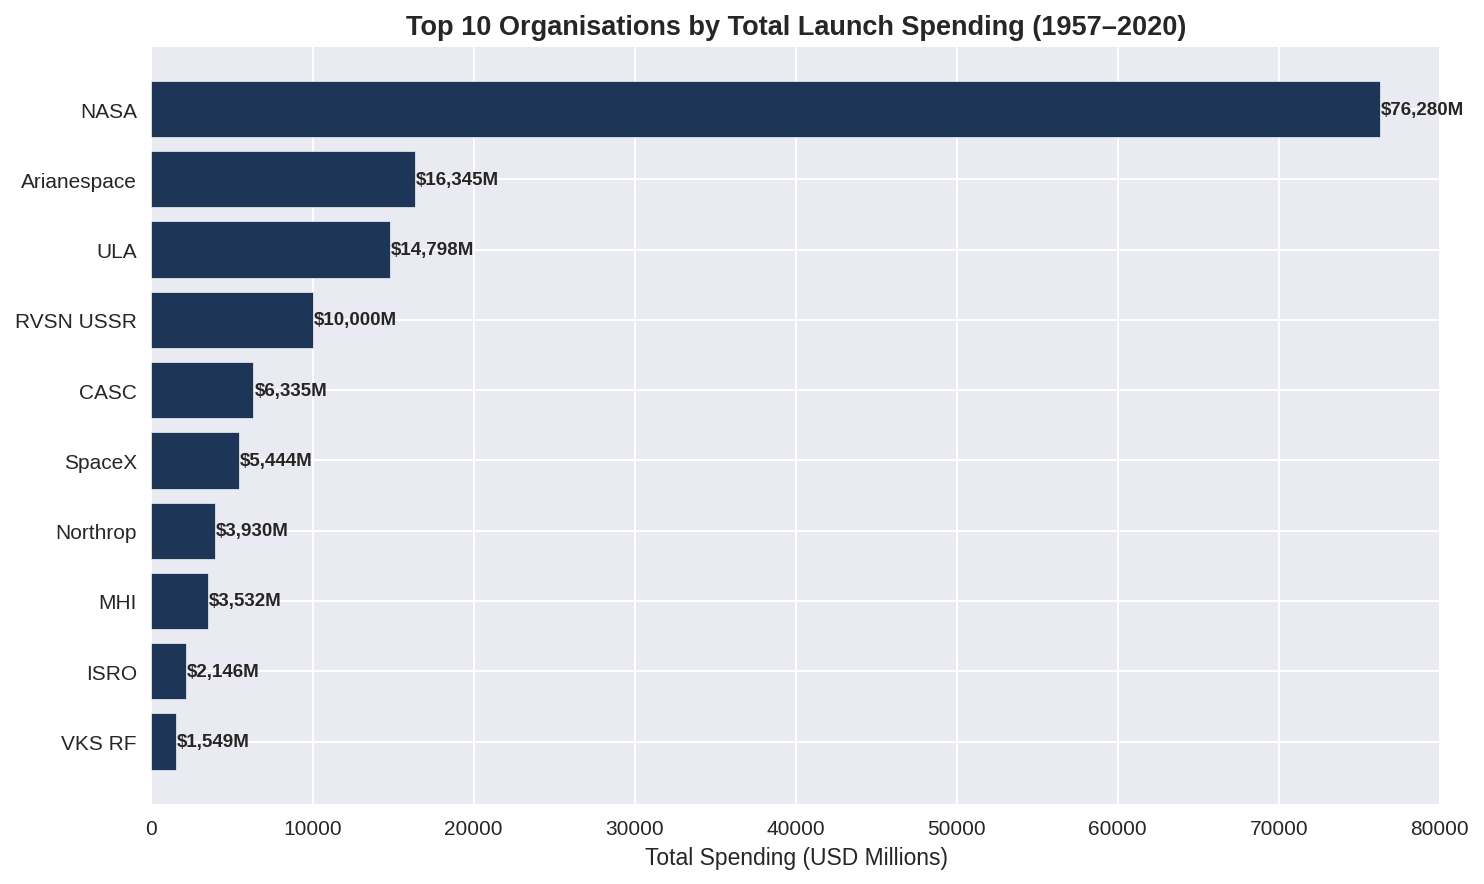

In [ ]:

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(top10_spending['Organisation'],
               top10_spending['Price'],
               color='#1d3557', edgecolor='white')

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 50,
            bar.get_y() + bar.get_height()/2,
            f'${width:,.0f}M',
            va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Total Spending (USD Millions)')
ax.set_title('Top 10 Organisations by Total Launch Spending (1957–2020)',
             fontweight='bold', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# What countries are not reporting cost of missions?

In [ ]:
# Missing price data by country
missing_price = clean_df[clean_df['Price'].isna()].groupby('country').size().reset_index()
missing_price.columns = ['country', 'missing_count']
missing_price = missing_price.sort_values('missing_count', ascending=False)

# Add total launches for context
total_by_country = clean_df.groupby('country').size().reset_index()
total_by_country.columns = ['country', 'total']

missing_price = missing_price.merge(total_by_country, on='country')
missing_price['missing_pct'] = (missing_price['missing_count'] / missing_price['total'] * 100).round(1)

print(missing_price.to_string(index=False))

                               country  missing_count  total  missing_pct
                    Russian Federation           1300   1354        96.00
                         United States            871   1359        64.10
                            Kazakhstan            635    679        93.50
                                France            208    303        68.60
                                 China            107    265        40.40
                                 Japan             82    122        67.20
                                 Kenya              9      9       100.00
                                 India              9     75        12.00
                             Australia              5      5       100.00
Korea, Democratic People's Republic of              5      5       100.00
                    Korea, Republic of              3      3       100.00
                                  Iran              3      3       100.00
                                Israel

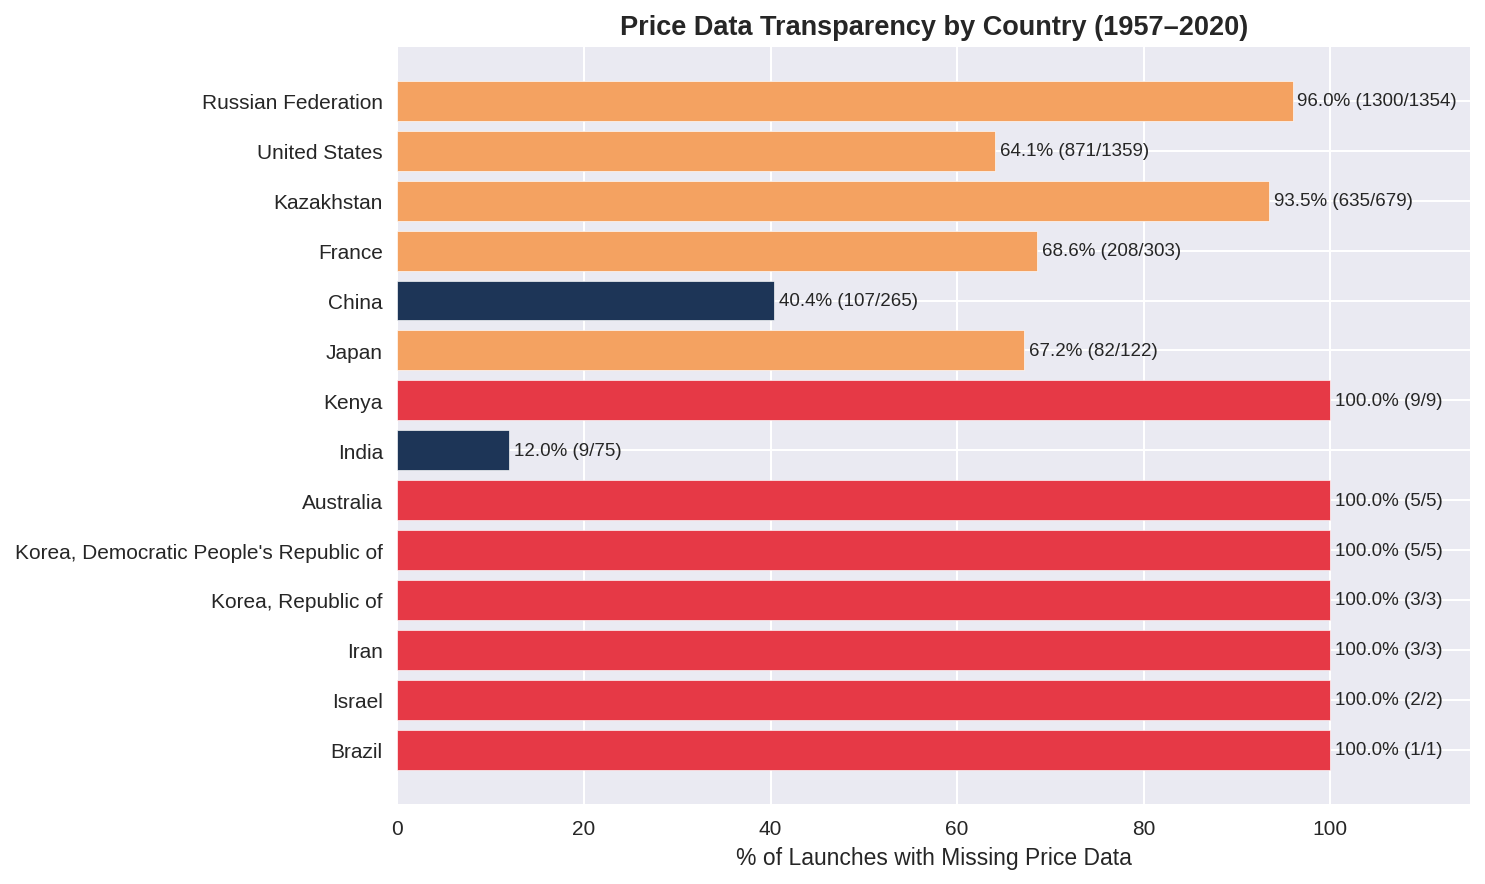

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(missing_price['country'],
               missing_price['missing_pct'],
               color=['#e63946' if pct == 100
                      else '#f4a261' if pct > 50
                      else '#1d3557'
                      for pct in missing_price['missing_pct']],
               edgecolor='white')

# Add labels
for bar, (_, row) in zip(bars, missing_price.iterrows()):
    width = bar.get_width()
    ax.text(width + 0.5,
            bar.get_y() + bar.get_height()/2,
            f'{width:.1f}% ({row["missing_count"]}/{row["total"]})',
            va='center', fontsize=9)

ax.set_xlabel('% of Launches with Missing Price Data')
ax.set_title('Price Data Transparency by Country (1957–2020)',
             fontweight='bold', fontsize=13)
ax.set_xlim(0, 115)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Known Total spending by Organization

In [ ]:
print(f"Total known spending: ${org_spending['Price'].sum():,.1f}M")
print(f"\nTop 10 spenders:\n{org_spending.head(10).to_string(index=False)}")

Total known spending: $148,087.4M

Top 10 spenders:
Organisation     Price
        NASA 76,280.00
 Arianespace 16,345.00
         ULA 14,798.00
   RVSN USSR 10,000.00
        CASC  6,334.96
      SpaceX  5,444.00
    Northrop  3,930.00
         MHI  3,532.50
        ISRO  2,146.00
      VKS RF  1,548.90


/tmp/ipykernel_8906/1955357099.py:58: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_8906/1955357099.py:58: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


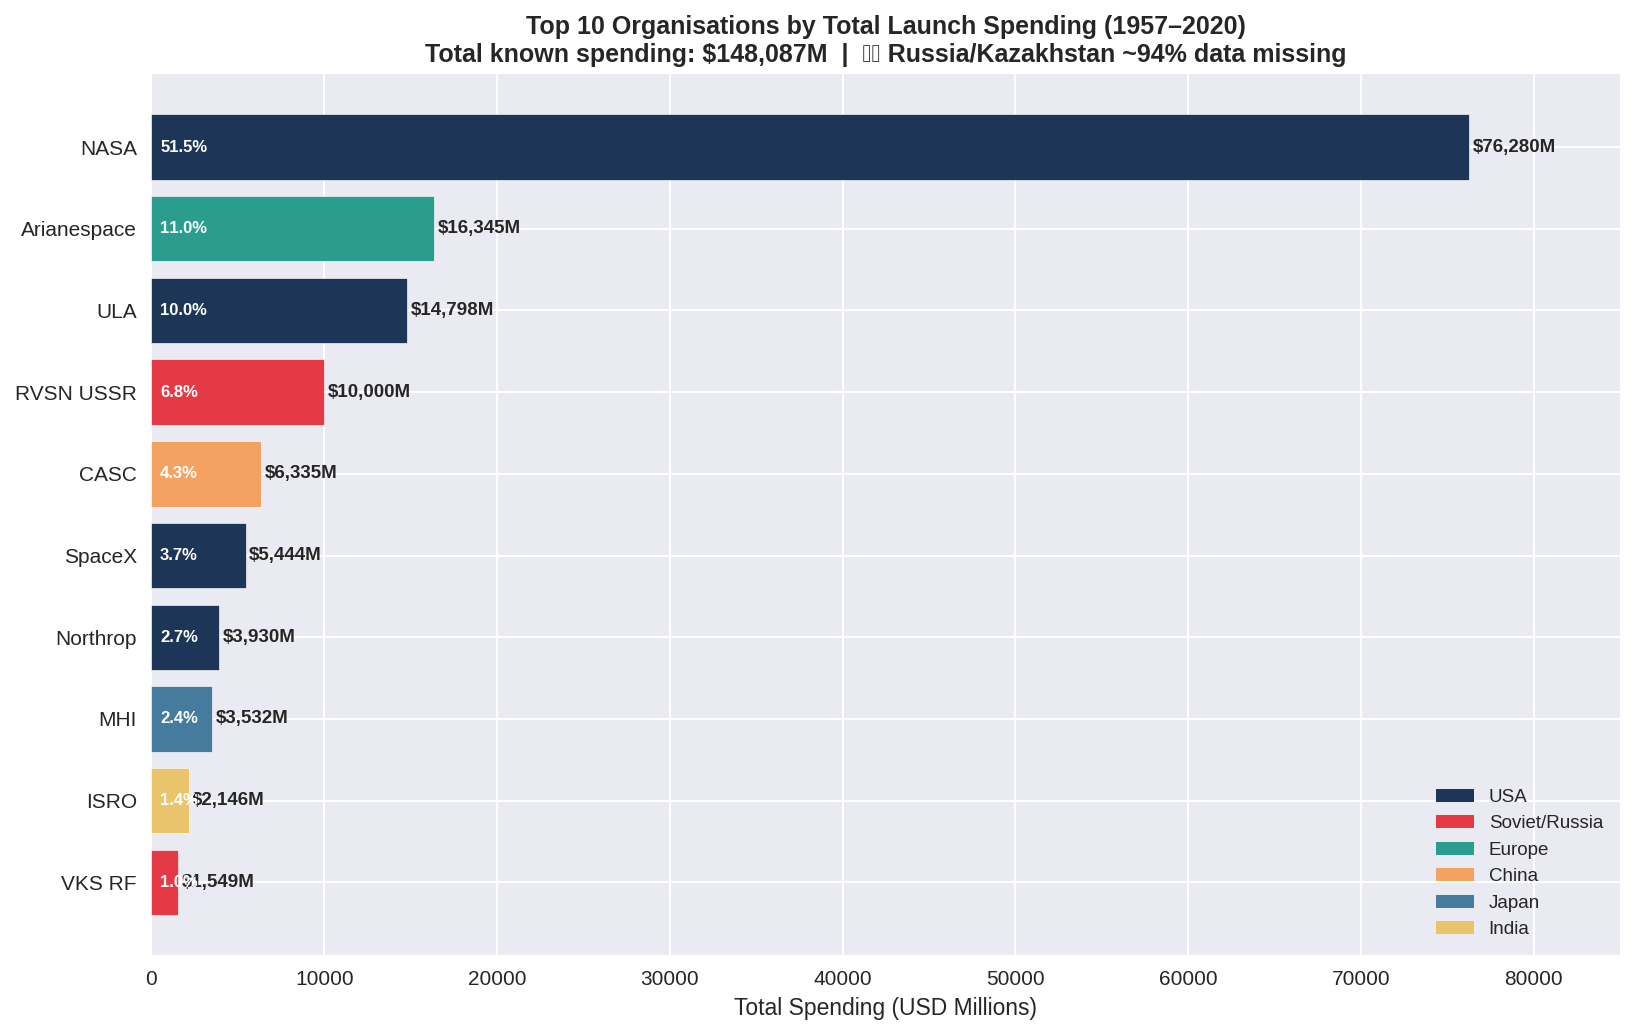

In [ ]:
top10_spending = org_spending.head(10)

# Color by country/origin
color_map = {
    'NASA':       '#1d3557',  # USA
    'ULA':        '#1d3557',  # USA
    'SpaceX':     '#1d3557',  # USA
    'Northrop':   '#1d3557',  # USA
    'Arianespace':'#2a9d8f',  # Europe
    'RVSN USSR':  '#e63946',  # Soviet
    'VKS RF':     '#e63946',  # Russia
    'CASC':       '#f4a261',  # China
    'MHI':        '#457b9d',  # Japan
    'ISRO':       '#e9c46a',  # India
}
colors = [color_map.get(org, '#adb5bd') for org in top10_spending['Organisation']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top10_spending['Organisation'],
               top10_spending['Price'],
               color=colors, edgecolor='white')

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 200,
            bar.get_y() + bar.get_height()/2,
            f'${width:,.0f}M',
            va='center', fontsize=9, fontweight='bold')

# Add % of total
for i, (bar, (_, row)) in enumerate(zip(bars, top10_spending.iterrows())):
    pct = row['Price'] / org_spending['Price'].sum() * 100
    ax.text(500,
            bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%',
            va='center', fontsize=8, color='white', fontweight='bold')

ax.set_xlabel('Total Spending (USD Millions)', fontsize=11)
ax.set_title('Top 10 Organisations by Total Launch Spending (1957–2020)\n'
             f'Total known spending: $148,087M  |  ⚠️ Russia/Kazakhstan ~94% data missing',
             fontweight='bold', fontsize=12)
ax.set_xlim(0, 85000)
ax.invert_yaxis()

# Add legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1d3557', label='USA'),
    Patch(facecolor='#e63946', label='Soviet/Russia'),
    Patch(facecolor='#2a9d8f', label='Europe'),
    Patch(facecolor='#f4a261', label='China'),
    Patch(facecolor='#457b9d', label='Japan'),
    Patch(facecolor='#e9c46a', label='India'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

## Analyze the Amount of Money Spent by Organization per Launch

In [ ]:
# Build the dataset
cost_analysis = (
    clean_df.dropna(subset=['Price'])
    .groupby('Organisation')
    .agg(
        total_spent  = ('Price', 'sum'),
        median_cost  = ('Price', 'median'),
        launch_count = ('Price', 'count')
    )
    .reset_index()
)

In [ ]:
cost_analysis.info() # check structure and datatype

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Organisation  24 non-null     object 
 1   total_spent   24 non-null     float64
 2   median_cost   24 non-null     float64
 3   launch_count  24 non-null     int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 900.0+ bytes


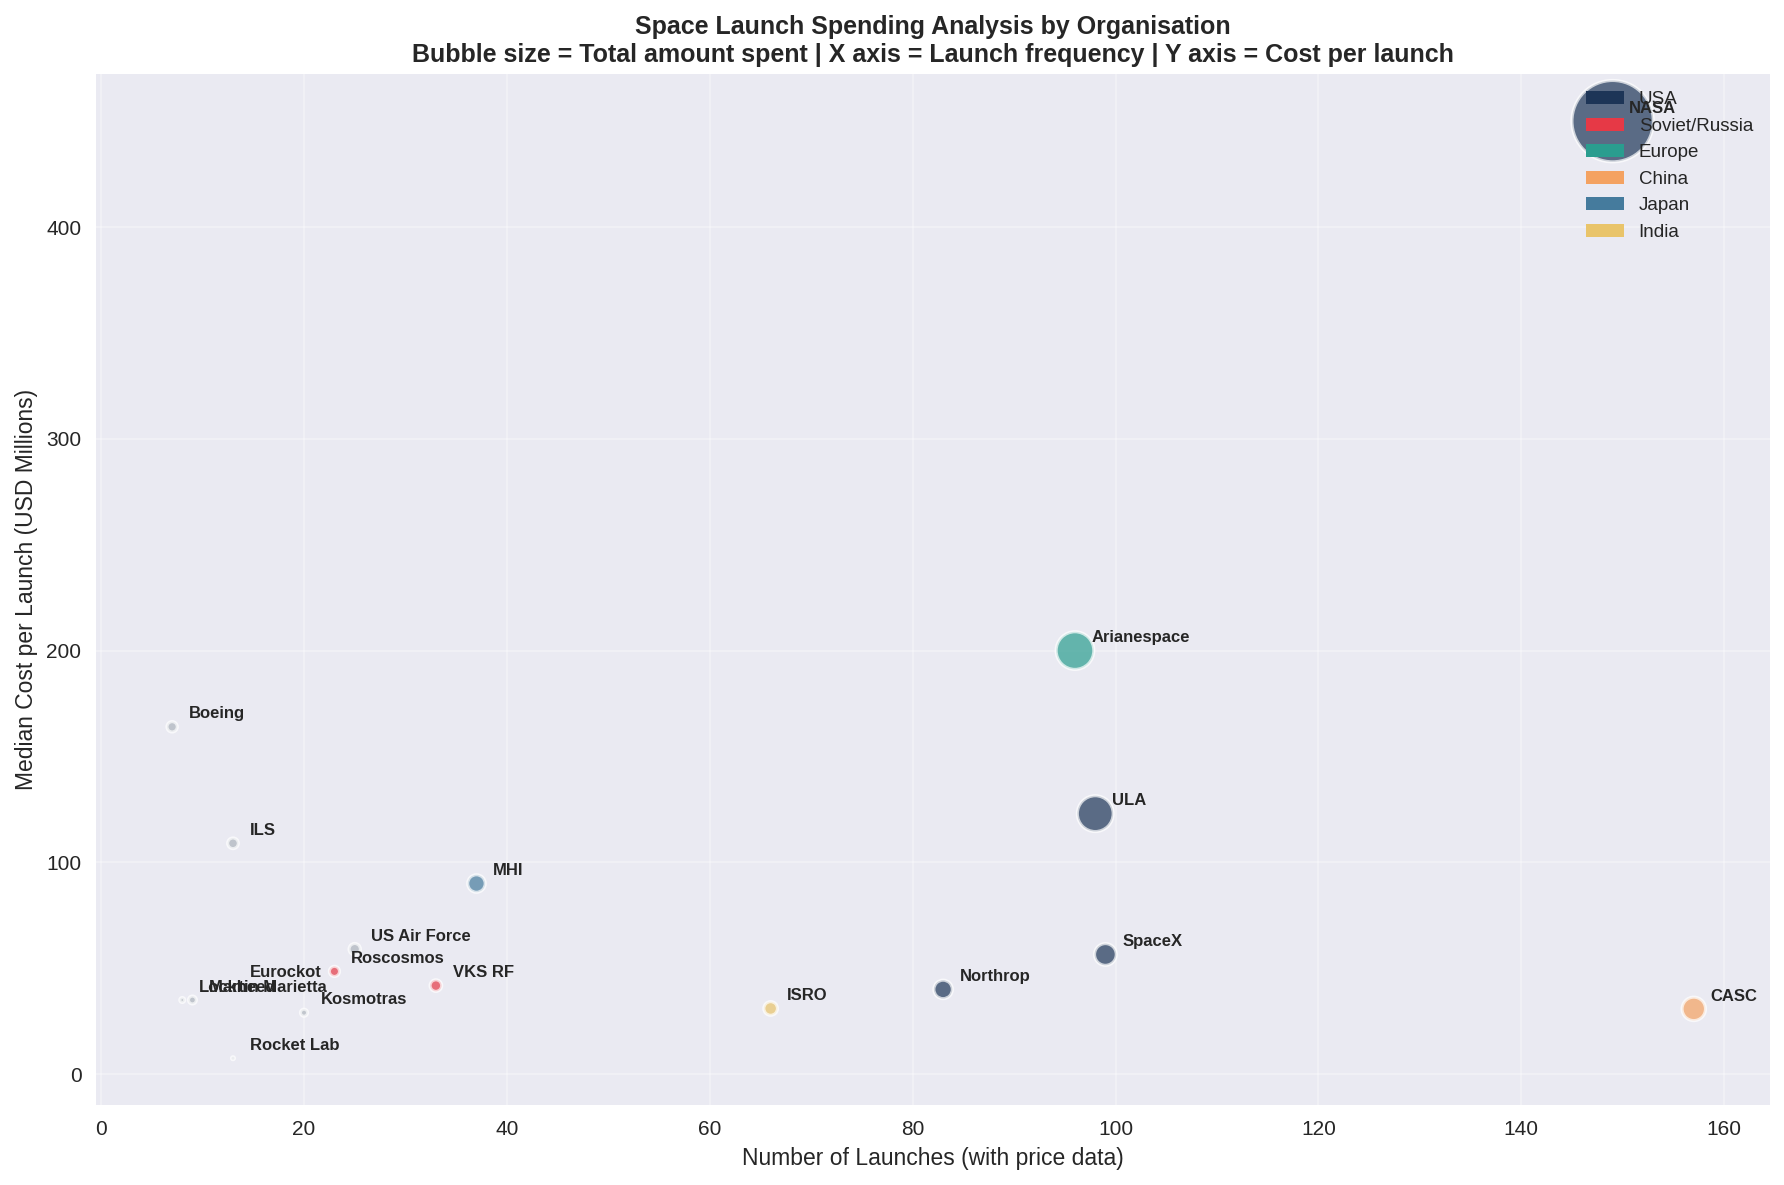

In [ ]:

# Filter 5+ launches
cost_analysis = cost_analysis[cost_analysis['launch_count'] >= 5]

color_map = {
    'NASA':       '#1d3557',
    'ULA':        '#1d3557',
    'SpaceX':     '#1d3557',
    'Northrop':   '#1d3557',
    'Arianespace':'#2a9d8f',
    'RVSN USSR':  '#e63946',
    'VKS RF':     '#e63946',
    'Roscosmos':  '#e63946',
    'CASC':       '#f4a261',
    'MHI':        '#457b9d',
    'ISRO':       '#e9c46a',
}
cost_analysis['color'] = cost_analysis['Organisation'].map(
    lambda x: color_map.get(x, '#adb5bd')
)

fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    cost_analysis['launch_count'],   # x = number of launches
    cost_analysis['median_cost'],    # y = cost per launch
    s=cost_analysis['total_spent'] / 50,  # bubble size = total spent
    c=cost_analysis['color'],
    alpha=0.7,
    edgecolors='white',
    linewidth=1.5
)

# Label each bubble
for _, row in cost_analysis.iterrows():
    ax.annotate(
        row['Organisation'],
        (row['launch_count'], row['median_cost']),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=8,
        fontweight='bold'
    )

ax.set_xlabel('Number of Launches (with price data)', fontsize=11)
ax.set_ylabel('Median Cost per Launch (USD Millions)', fontsize=11)
ax.set_title('Space Launch Spending Analysis by Organisation\n'
             'Bubble size = Total amount spent | X axis = Launch frequency | Y axis = Cost per launch',
             fontweight='bold', fontsize=12)

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1d3557', label='USA'),
    Patch(facecolor='#e63946', label='Soviet/Russia'),
    Patch(facecolor='#2a9d8f', label='Europe'),
    Patch(facecolor='#f4a261', label='China'),
    Patch(facecolor='#457b9d', label='Japan'),
    Patch(facecolor='#e9c46a', label='India'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Average cost per organization

In [ ]:
# Calculate and sort average cost
avg_cost = (
    clean_df.dropna(subset=['Price'])
    .groupby('Organisation')['Price']
    .agg(mean_cost='mean', launch_count='count')
    .reset_index()
)

# Filter Organizations with 5+ launches for statistical relevance
avg_cost = avg_cost[avg_cost['launch_count'] >= 5]
avg_cost = avg_cost.sort_values('mean_cost', ascending=False)

print(f"Organisations included: {len(avg_cost)}")
print(avg_cost.to_string(index=False))

Organisations included: 18
   Organisation  mean_cost  launch_count
           NASA     511.95           149
         Boeing     177.29             7
    Arianespace     170.26            96
            ULA     151.00            98
            ILS     101.54            13
            MHI      95.47            37
Martin Marietta      80.16             9
   US Air Force      59.68            25
         SpaceX      54.99            99
      Roscosmos      51.63            23
       Northrop      47.35            83
         VKS RF      46.94            33
       Eurockot      41.80            13
           CASC      40.35           157
       Lockheed      35.00             8
           ISRO      32.52            66
      Kosmotras      29.00            20
     Rocket Lab       7.50            13


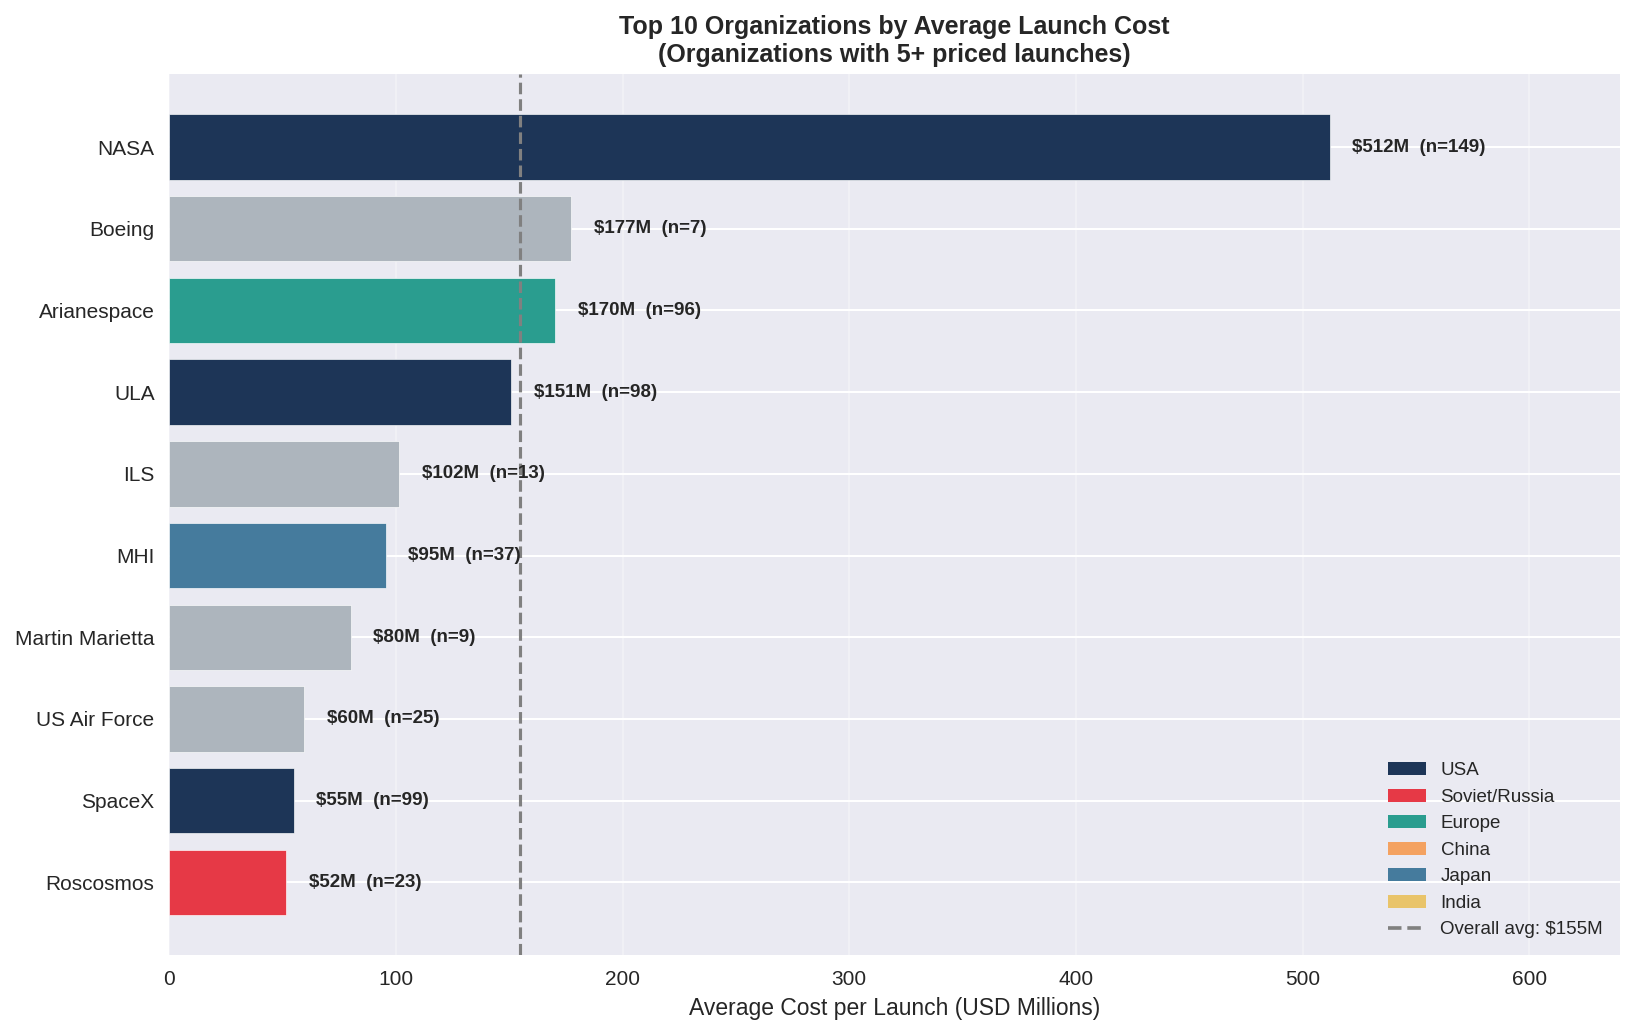

In [ ]:
top10_avg = avg_cost.head(10).sort_values('mean_cost', ascending=True)

color_map = {
    'NASA':       '#1d3557',
    'ULA':        '#1d3557',
    'SpaceX':     '#1d3557',
    'Northrop':   '#1d3557',
    'Arianespace':'#2a9d8f',
    'RVSN USSR':  '#e63946',
    'VKS RF':     '#e63946',
    'Roscosmos':  '#e63946',
    'CASC':       '#f4a261',
    'MHI':        '#457b9d',
    'ISRO':       '#e9c46a',
}
colors = [color_map.get(org, '#adb5bd') for org in top10_avg['Organisation']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top10_avg['Organisation'],
               top10_avg['mean_cost'],
               color=colors, edgecolor='white')

for bar, (_, row) in zip(bars, top10_avg.iterrows()):
    width = bar.get_width()
    ax.text(width + 10,
            bar.get_y() + bar.get_height()/2,
            f'${width:,.0f}M  (n={int(row["launch_count"])})',
            va='center', fontsize=9, fontweight='bold')

# Add overall average line
overall_avg = clean_df['Price'].mean()
ax.axvline(overall_avg, color='gray', linestyle='--', linewidth=1.5,
           label=f'Overall avg: ${overall_avg:,.0f}M')

ax.set_xlabel('Average Cost per Launch (USD Millions)', fontsize=11)
ax.set_title('Top 10 Organizations by Average Launch Cost\n'
             '(Organizations with 5+ priced launches)',
             fontweight='bold', fontsize=12)
ax.set_xlim(0, top10_avg['mean_cost'].max() * 1.25)
ax.legend(fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1d3557', label='USA'),
    Patch(facecolor='#e63946', label='Soviet/Russia'),
    Patch(facecolor='#2a9d8f', label='Europe'),
    Patch(facecolor='#f4a261', label='China'),
    Patch(facecolor='#457b9d', label='Japan'),
    Patch(facecolor='#e9c46a', label='India'),
]
ax.legend(handles=legend_elements + [
    plt.Line2D([0], [0], color='gray', linestyle='--', label=f'Overall avg: ${overall_avg:,.0f}M')
], loc='lower right', fontsize=9)

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
# Chart the Number of Launches per Year

In [ ]:
clean_df['Date'] = pd.to_datetime(clean_df['Date'], utc=True)
clean_df[['Date','Year']].head()

,Date,Year
0,2020-08-07 05:12:00+00:00,2020
1,2020-08-06 04:01:00+00:00,2020
2,2020-08-04 23:57:00+00:00,2020
3,2020-07-30 21:25:00+00:00,2020
4,2020-07-30 11:50:00+00:00,2020


Count Launches per year

In [ ]:
yearly_launches = clean_df.groupby('Year').size().reset_index(name='launch_count')



Year with the most launches

In [ ]:
yearly_launches.loc[yearly_launches['launch_count'].idxmax()]
peak_idx = yearly_launches['launch_count'].idxmax()
peak = yearly_launches.loc[peak_idx]
print(f"Peak year: {peak['Year']} with {peak['launch_count']} launches")

Peak year: 2018 with 117 launches


In [ ]:
import plotly.express as px

fig = px.line(
    yearly_launches,
    x='Year',
    y='launch_count',
    title='Number of Space Launches per Year',
    labels={'launch_count':'Number of Launches'}
)

fig.show()

In [ ]:


# Define peaks
peak_idx = yearly_launches['launch_count'].idxmax()
peak = yearly_launches.loc[peak_idx]
print(f"Peak year: {int(peak['Year'])} with {int(peak['launch_count'])} launches")

# Helper to get launch count for a specific year
def get_count(year):
    row = yearly_launches[yearly_launches['Year'] == year]
    return int(row['launch_count'].values[0]) if len(row) > 0 else 0

fig = px.line(
    yearly_launches,
    x='Year',
    y='launch_count',
    title='Number of Space Launches per Year (1957–2020)',
    labels={'launch_count': 'Number of Launches'},
    markers=True
)

# Shaded eras
fig.add_vrect(x0=1957, x1=1991, fillcolor='lightblue', opacity=0.1,
              annotation_text='Cold War', annotation_position='top left')
fig.add_vrect(x0=1991, x1=2010, fillcolor='lightyellow', opacity=0.1,
              annotation_text='Post Cold War', annotation_position='top left')
fig.add_vrect(x0=2010, x1=2020, fillcolor='lightgreen', opacity=0.1,
              annotation_text='Commercial Era', annotation_position='top left')

# Annotations using actual y values
fig.add_annotation(x=1957, y=get_count(1957),
                   text="🛰️ Sputnik", showarrow=True, arrowhead=2, ay=-40)
fig.add_annotation(x=1969, y=get_count(1969),
                   text="🌙 Moon Landing", showarrow=True, arrowhead=2, ay=-40)
fig.add_annotation(x=1991, y=get_count(1991),
                   text="🏳️ USSR Collapse", showarrow=True, arrowhead=2, ay=-40)
fig.add_annotation(x=int(peak['Year']), y=int(peak['launch_count']),
                   text=f"🚀 Peak: {int(peak['launch_count'])}",
                   showarrow=True, arrowhead=2, ay=-40)

fig.update_layout(
    title_x=0.5,
    title_font_size=16,
    hovermode='x unified',
    xaxis=dict(dtick=5),
    plot_bgcolor='white',
    yaxis=dict(gridcolor='lightgray'),
    xaxis_gridcolor='lightgray'
)

fig.update_traces(line_color='#1d3557', line_width=2.5,
                  marker=dict(size=5, color='#e63946'))

fig.show()

Peak year: 2018 with 117 launches


# A more in depth insight

Adding a rolling average

In [ ]:
# Create rolling average column first
yearly_launches['rolling_avg'] = yearly_launches['launch_count'].rolling(window=5, center=True).mean().round(1)

print(yearly_launches.head(10))  # verify column is there

   Year  launch_count  rolling_avg
0  1957             3          NaN
1  1958            22          NaN
2  1959            20        27.00
3  1960            38        42.60
4  1961            52        45.80
5  1962            81        53.00
6  1963            38        62.60
7  1964            56        71.80
8  1965            86        76.00
9  1966            98        88.40


In [ ]:
yearly_launches['rolling_avg'] = (
    yearly_launches['launch_count']
    .rolling(window=5, center=True, min_periods=1)
    .mean()
    .round(1)
)

print(yearly_launches.head(6))

   Year  launch_count  rolling_avg
0  1957             3        15.00
1  1958            22        20.80
2  1959            20        27.00
3  1960            38        42.60
4  1961            52        45.80
5  1962            81        53.00


In [ ]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=yearly_launches['Year'],
    y=yearly_launches['launch_count'],
    mode='lines+markers',
    name='Yearly Launches'
))

fig.add_trace(go.Scatter(
    x=yearly_launches['Year'],
    y=yearly_launches['rolling_avg'],
    mode='lines',
    name='5-Year Rolling Average',
    line=dict(width=4)
))

fig.update_layout(
    title="Space Launches per Year",
    xaxis_title="Year",
    yaxis_title="Number of Launches",
    template="plotly_white"
)

fig.show()

In [ ]:


# Define peaks
peak_idx = yearly_launches['launch_count'].idxmax()
peak = yearly_launches.loc[peak_idx]
print(f"Peak year: {int(peak['Year'])} with {int(peak['launch_count'])} launches")

# Helper to get launch count for a specific year
def get_count(year):
    row = yearly_launches[yearly_launches['Year'] == year]
    return int(row['launch_count'].values[0]) if len(row) > 0 else 0

fig = px.line(
    yearly_launches,
    x='Year',
    y='launch_count',
    title='Number of Space Launches per Year (1957–2020)',
    labels={'launch_count': 'Number of Launches'},
    markers=True
)

# Style ONLY the main line using selector
fig.update_traces(
    selector=dict(name='launch_count'),
    line=dict(color='#1d3557', width=2.5),
    marker=dict(size=5, color='#1d3557')
)


# Rolling average
fig.add_trace(go.Scatter(
    x=yearly_launches['Year'],
    y=yearly_launches['rolling_avg'],
    mode='lines',
    name='5-Year Rolling Average',
    line=dict(color='#e63946', width=3)
))

# Shaded eras
fig.add_vrect(x0=1957, x1=1991, fillcolor='lightblue', opacity=0.1,
              annotation_text='Cold War', annotation_position='top left')
fig.add_vrect(x0=1991, x1=2010, fillcolor='lightyellow', opacity=0.1,
              annotation_text='Post Cold War', annotation_position='top left')
fig.add_vrect(x0=2010, x1=2020, fillcolor='lightgreen', opacity=0.1,
              annotation_text='Commercial Era', annotation_position='top left')

# Annotations using actual y values
fig.add_annotation(x=1957, y=get_count(1957),
                   text="🛰️ Sputnik", showarrow=True, arrowhead=2, ay=-40)
fig.add_annotation(x=1969, y=get_count(1969),
                   text="🌙 Moon Landing", showarrow=True, arrowhead=2, ay=-40)
fig.add_annotation(x=1991, y=get_count(1991),
                   text="🏳️ USSR Collapse", showarrow=True, arrowhead=2, ay=-40)
fig.add_annotation(x=int(peak['Year']), y=int(peak['launch_count']),
                   text=f"🚀 Peak: {int(peak['launch_count'])}",
                   showarrow=True, arrowhead=2, ay=-40)

fig.update_layout(
    title_x=0.5,
    title_font_size=16,
    hovermode='x unified',
    xaxis=dict(dtick=5),
    plot_bgcolor='white',
    yaxis=dict(gridcolor='lightgray'),
    xaxis_gridcolor='lightgray'
)


fig.show()

Peak year: 2018 with 117 launches


# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart.

In [ ]:
clean_df['Year'] = clean_df['Date'].dt.year

Create a month column



In [ ]:
# Month column as period
clean_df['Month'] = clean_df['Date'].dt.to_period('M')

/tmp/ipykernel_8906/2080136138.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  clean_df['Month'] = clean_df['Date'].dt.to_period('M')


Count lounches per month

In [ ]:
monthly_launches = clean_df.groupby('Month').size().reset_index(name='launch_count')

Convert back to times stamp for plotting

In [ ]:
monthly_launches['Month'] = monthly_launches['Month'].dt.to_timestamp()

Calculate the Rolling average

In [ ]:
# Rolling average with no NaNs
monthly_launches['rolling_avg'] = (
  monthly_launches['launch_count']
  .rolling(window=12).
  mean()
  .round(1)
  )

Month with the highest number of launches

In [ ]:

#Peak month
peak_month = monthly_launches.loc[monthly_launches['launch_count'].idxmax()]
print(f"Peak month: {peak_month['Month'].strftime('%B %Y')} "
      f"with {int(peak_month['launch_count'])} launches")

Peak month: April 1968 with 16 launches


In [ ]:



# Plot
fig = go.Figure()

# Monthly launches
fig.add_trace(go.Scatter(
    x=monthly_launches['Month'],
    y=monthly_launches['launch_count'],
    mode='lines',
    name='Monthly Launches',
    line=dict(color='#1d3557', width=1),
    opacity=0.6
))

# Rolling average
fig.add_trace(go.Scatter(
    x=monthly_launches['Month'],
    y=monthly_launches['rolling_avg'],
    mode='lines',
    name='12-Month Rolling Average',
    line=dict(color='#e63946', width=3)
))

# Peak annotation
fig.add_annotation(
    x=peak_month['Month'],
    y=int(peak_month['launch_count']),
    text=f"🚀 Peak: {int(peak_month['launch_count'])} launches<br>"
         f"{peak_month['Month'].strftime('%B %Y')}",
    showarrow=True, arrowhead=2, ay=-40,
    font=dict(size=11)
)

# Shaded eras
fig.add_vrect(x0='1957-01-01', x1='1991-01-01', fillcolor='lightblue', opacity=0.1,
              annotation_text='Cold War', annotation_position='top left')
fig.add_vrect(x0='1991-01-01', x1='2010-01-01', fillcolor='lightyellow', opacity=0.1,
              annotation_text='Post Cold War', annotation_position='top left')
fig.add_vrect(x0='2010-01-01', x1='2020-12-01', fillcolor='lightgreen', opacity=0.1,
              annotation_text='Commercial Era', annotation_position='top left')

fig.update_layout(
    title=dict(
        text='Space Launches Month-by-Month (1957–2020)',
        x=0.5, font_size=16
    ),
    xaxis_title='Year',
    yaxis_title='Number of Launches',
    template='plotly_white',
    hovermode='x unified',
    legend=dict(x=0.01, y=0.99)
)

fig.show()

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

In [ ]:
clean_df['Year'] = clean_df['Date'].dt.year
clean_df['Month'] = clean_df['Date'].dt.month

In [ ]:
clean_df['Month_Name'] = clean_df['Date'].dt.month_name()

In [ ]:
clean_df['Year'] = clean_df['Year'].astype(int)
clean_df['Month'] = clean_df['Month'].astype(int)

In [ ]:
clean_df[['Year','Month']].dtypes # check year and month are in the correct format

,0
Year,int64
Month,int64


In [ ]:
clean_df[['Date','Year','Month','Month_Name']].head()

,Date,Year,Month,Month_Name
0,2020-08-07 05:12:00+00:00,2020,8,August
1,2020-08-06 04:01:00+00:00,2020,8,August
2,2020-08-04 23:57:00+00:00,2020,8,August
3,2020-07-30 21:25:00+00:00,2020,7,July
4,2020-07-30 11:50:00+00:00,2020,7,July


In [ ]:
# Count launches per month across all years
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_popularity = (
    clean_df.groupby(['Month', 'Month_Name'])
    .size()
    .reset_index(name='launch_count')
    .sort_values('Month')  # sort by month number not name
)

# Add percentage of total
monthly_popularity['pct'] = (
    monthly_popularity['launch_count'] / monthly_popularity['launch_count'].sum() * 100
).round(1)

print("Launches by Month (all years combined):")
print(monthly_popularity[['Month_Name', 'launch_count', 'pct']].to_string(index=False))
print(f"\nBusiest month : {monthly_popularity.loc[monthly_popularity['launch_count'].idxmax(), 'Month_Name']}")
print(f"Quietest month: {monthly_popularity.loc[monthly_popularity['launch_count'].idxmin(), 'Month_Name']}")

Launches by Month (all years combined):
Month_Name  launch_count   pct
   January           265  6.30
  February           323  7.70
     March           349  8.30
     April           366  8.70
       May           320  7.60
      June           386  9.20
      July           347  8.30
    August           358  8.50
 September           354  8.40
   October           375  8.90
  November           325  7.70
  December           430 10.20

Busiest month : December
Quietest month: January


# Plot Monthly Popularity

In [ ]:
#plot

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Barpolar(
    r=monthly_popularity['launch_count'],
    theta=monthly_popularity['Month_Name'],
    marker=dict(
        color=monthly_popularity['launch_count'],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title='Launches')
    ),
    hovertemplate='<b>%{theta}</b><br>Launches: %{r}<extra></extra>'
))

fig.update_layout(
    title=dict(text='Space Launches by Month (1957–2020)', x=0.5, font_size=16),
    polar=dict(
        radialaxis=dict(showticklabels=True, ticks=''),
        angularaxis=dict(direction='clockwise')
    ),
    template='plotly_white'
)

fig.show()

# Visualize this with a bar chart

/tmp/ipykernel_8906/466002721.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(monthly_popularity['Month_Name'], rotation=45)


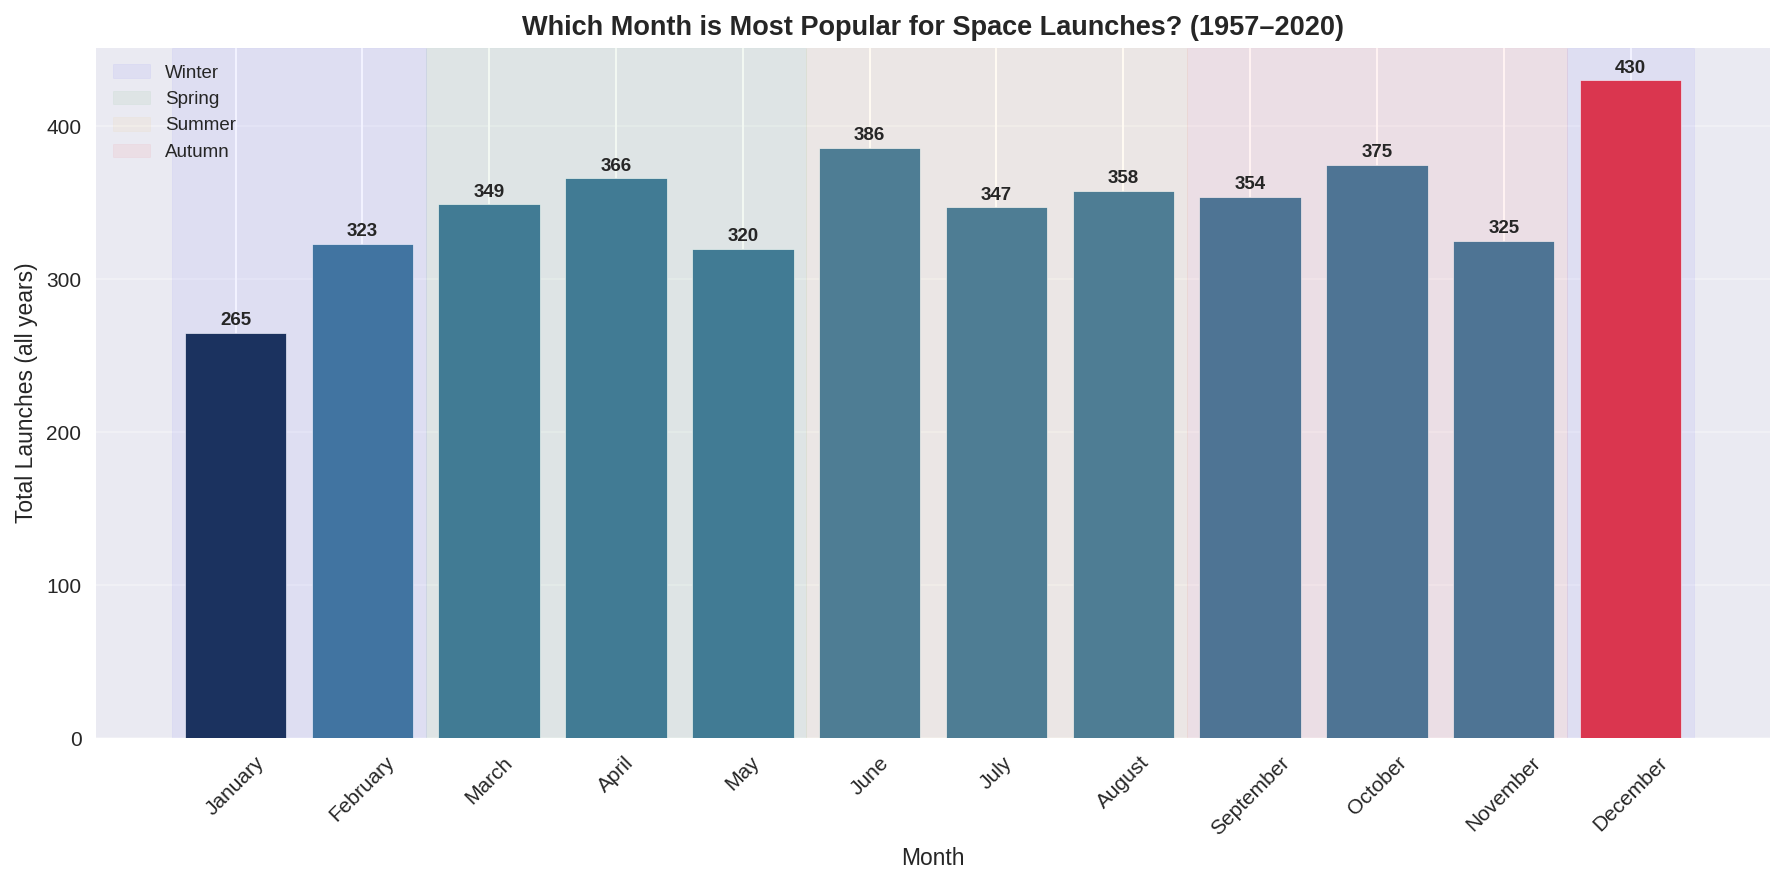

In [ ]:
colors = ['#e63946' if c == monthly_popularity['launch_count'].max()
          else '#1d3557' if c == monthly_popularity['launch_count'].min()
          else '#457b9d'
          for c in monthly_popularity['launch_count']]

fig2, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(monthly_popularity['Month_Name'],
              monthly_popularity['launch_count'],
              color=colors, edgecolor='white')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            height + 5, str(int(height)),
            ha='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Launches (all years)', fontsize=11)
ax.set_title('Which Month is Most Popular for Space Launches? (1957–2020)',
             fontweight='bold', fontsize=13)
ax.set_xticklabels(monthly_popularity['Month_Name'], rotation=45)

# Add seasonal shading
ax.axvspan(-0.5, 1.5,  alpha=0.05, color='blue',  label='Winter')
ax.axvspan(1.5,  4.5,  alpha=0.05, color='green', label='Spring')
ax.axvspan(4.5,  7.5,  alpha=0.05, color='orange',label='Summer')
ax.axvspan(7.5,  10.5, alpha=0.05, color='red',   label='Autumn')
ax.axvspan(10.5, 11.5, alpha=0.05, color='blue')

ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# How has the Launch Price varied Over Time?

Create a line chart that shows the average price of rocket launches over time.

In [ ]:
# Average price per year (only years with enough data)
price_over_time = (
    clean_df.dropna(subset=['Price'])
    .groupby('Year')
    .agg(
        avg_price    = ('Price', 'mean'),
        median_price = ('Price', 'median'),
        count        = ('Price', 'count')
    )
    .reset_index()
)

# Filter years with at least 3 priced launches for statistical relevance
price_over_time = price_over_time[price_over_time['count'] >= 3]

# Rolling average to smooth the trend
price_over_time['rolling_avg'] = (
    price_over_time['avg_price']
    .rolling(window=5, center=True, min_periods=1)
    .mean()
    .round(1)
)

print(f"Years with 3+ priced launches: {len(price_over_time)}")
print(price_over_time.to_string(index=False))

Years with 3+ priced launches: 43
 Year  avg_price  median_price  count  rolling_avg
 1966      59.00         59.00      3       184.80
 1967     216.29         59.00      7       291.00
 1968     279.20         59.00     10       301.80
 1969     609.50        609.50      8       363.30
 1982     345.20        450.00      4       396.00
 1983     366.16        450.00      5       421.80
 1984     380.13        450.00      6       362.00
 1985     408.08        450.00     10       630.40
 1986     310.27        450.00      3       795.80
 1987   1,687.20         30.80      3       795.90
 1988   1,193.16        450.00      5       772.10
 1989     380.83        450.00      6       788.40
 1990     289.15        450.00     11       514.80
 1991     391.43        450.00      7       331.50
 1992     319.35        450.00     12       299.60
 1993     276.73        450.00     12       306.80
 1994     221.51         69.70     16       277.20
 1995     325.00        450.00     10       257.

In [ ]:
fig = go.Figure()

# Average price per year
fig.add_trace(go.Scatter(
    x=price_over_time['Year'],
    y=price_over_time['avg_price'],
    mode='lines+markers',
    name='Avg Price per Year',
    line=dict(color='#1d3557', width=1.5),
    marker=dict(size=5),
    opacity=0.6,
    hovertemplate='<b>%{x}</b><br>Avg: $%{y:,.1f}M<extra></extra>'
))

# Median price per year
fig.add_trace(go.Scatter(
    x=price_over_time['Year'],
    y=price_over_time['median_price'],
    mode='lines',
    name='Median Price per Year',
    line=dict(color='#2a9d8f', width=1.5, dash='dot'),
    opacity=0.8,
    hovertemplate='<b>%{x}</b><br>Median: $%{y:,.1f}M<extra></extra>'
))

# Rolling average
fig.add_trace(go.Scatter(
    x=price_over_time['Year'],
    y=price_over_time['rolling_avg'],
    mode='lines',
    name='5-Year Rolling Average',
    line=dict(color='#e63946', width=3),
    hovertemplate='<b>%{x}</b><br>Rolling Avg: $%{y:,.1f}M<extra></extra>'
))

# Shaded eras
fig.add_vrect(x0=1957, x1=1991, fillcolor='lightblue', opacity=0.1,
              annotation_text='Cold War', annotation_position='top left')
fig.add_vrect(x0=1991, x1=2010, fillcolor='lightyellow', opacity=0.1,
              annotation_text='Post Cold War', annotation_position='top left')
fig.add_vrect(x0=2010, x1=2020, fillcolor='lightgreen', opacity=0.1,
              annotation_text='Commercial Era', annotation_position='top left')

fig.update_layout(
    title=dict(
        text='Average Launch Price Over Time (1957–2020)<br>'
             '<sup>Based on reported costs only — ~94% of Russian launches excluded</sup>',
        x=0.5, font_size=15
    ),
    xaxis_title='Year',
    yaxis_title='Launch Price (USD Millions)',
    template='plotly_white',
    hovermode='x unified',
    xaxis=dict(dtick=5),
    legend=dict(x=0.01, y=0.99)
)

fig.add_annotation(
    x=1987, y=1687,
    text="Space Shuttle<br>peak cost era",
    showarrow=True, arrowhead=2, ay=-40,
    font=dict(size=10)
)

fig.add_annotation(
    x=1969, y=609,
    text="🌙 Apollo era",
    showarrow=True, arrowhead=2, ay=-40,
    font=dict(size=10)
)

fig.show()

# Chart the Number of Launches over Time by the Top 10 Organizations.

How has the dominance of launches changed over time between the different players?

In [ ]:
# See all 55 organisations and their total launches
all_orgs = (
    clean_df.groupby('Organisation')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='launch_count')
)
print(all_orgs.to_string(index=False))

    Organisation  launch_count
       RVSN USSR          1717
     Arianespace           279
General Dynamics           249
            CASC           249
            NASA           203
          VKS RF           198
    US Air Force           157
             ULA           140
          Boeing           136
 Martin Marietta           108
          SpaceX           100
             MHI            84
        Northrop            83
        Lockheed            79
            ISRO            75
       Roscosmos            55
             ILS            46
      Sea Launch            32
            ISAS            30
       Kosmotras            20
      Rocket Lab            13
        Eurockot            13
             ESA            13
         US Navy            11
          ExPace            10
             ASI             9
            CNES             8
     Land Launch             7
            JAXA             7
            MITT             7
            AMBA             7
     Blu

In [ ]:
org_mapping = {
    # Soviet/Russia (2001+ launches combined)
    'RVSN USSR':        'Soviet/Russia',
    'VKS RF':           'Soviet/Russia',
    'Roscosmos':        'Soviet/Russia',
    'Kosmotras':        'Soviet/Russia',
    'Land Launch':      'Soviet/Russia',
    'Starsem':          'Soviet/Russia',
    'Khrunichev':       'Soviet/Russia',
    'Yuzhmash':         'Soviet/Russia',
    'OKB-586':          'Soviet/Russia',
    'SRC':              'Soviet/Russia',

    # USA Government/Military
    'NASA':             'NASA',
    'US Air Force':     'US Military',
    'US Navy':          'US Military',
    'MITT':             'US Military',  # MIT Lincoln Lab - military research

    # USA Commercial (legacy - pre ULA merger)
    'General Dynamics': 'USA Commercial',
    'Martin Marietta':  'USA Commercial',
    'Lockheed':         'USA Commercial',
    'Boeing':           'USA Commercial',
    'ILS':              'USA Commercial',
    'Sea Launch':       'USA Commercial',
    'Douglas':          'USA Commercial',
    'EER':              'USA Commercial',

    # USA Commercial (modern)
    'ULA':              'ULA',
    'SpaceX':           'SpaceX',
    'Northrop':         'Northrop',
    'Rocket Lab':       'New Space',
    'Blue Origin':      'New Space',
    'Virgin Orbit':     'New Space',
    'Exos':             'New Space',

    # Europe
    'Arianespace':      'Arianespace',
    'ESA':              'Europe',
    'CNES':             'Europe',
    'Eurockot':         'Europe',
    'ASI':              'Europe',
    'CECLES':           'Europe',
    'Arm\u00e9e de l\'Air': 'Europe',
    'RAE':              'Europe',

    # China
    'CASC':             'China',
    'CASIC':            'China',
    'ExPace':           'China',
    'KCST':             'China',
    'Landspace':        'China',
    'OneSpace':         'China',
    'i-Space':          'China',

    # Japan
    'MHI':              'Japan',
    'JAXA':             'Japan',
    'ISAS':             'Japan',

    # India
    'ISRO':             'ISRO',

    # Other
    'KARI':             'South Korea',
    'IAI':              'Israel',
    'ISA':              'Israel',
    'IRGC':             'Iran',
    'AEB':              'Brazil',
    'AMBA':             'Other',
    'UT':               'Other',
}

# Apply mapping
clean_df['Org_Group'] = clean_df['Organisation'].map(org_mapping).fillna('Other')

# Verify
print("=== Group totals ===")
print(clean_df.groupby('Org_Group').size().sort_values(ascending=False).to_string())

print("\n=== Remaining in Other ===")
print(clean_df[clean_df['Org_Group'] == 'Other']
      .groupby('Organisation').size()
      .sort_values(ascending=False).to_string())

=== Group totals ===
Org_Group
Soviet/Russia     2005
USA Commercial     652
Arianespace        279
China              270
NASA               203
US Military        175
ULA                140
Japan              121
SpaceX             100
Northrop            83
ISRO                75
Europe              49
New Space           25
Other               12
Israel               4
South Korea          3
Brazil               1
Iran                 1

=== Remaining in Other ===
Organisation
AMBA               7
Arm??e de l'Air    4
UT                 1


In [ ]:
# Fix encoding issue and remap remaining
clean_df['Org_Group'] = clean_df['Org_Group'].replace({'Other': 'Europe'})

# Verify - Other should now be gone
print("=== Final Group totals ===")
group_totals = (clean_df.groupby('Org_Group')
                .size()
                .sort_values(ascending=False))
print(group_totals.to_string())

=== Final Group totals ===
Org_Group
Soviet/Russia     2005
USA Commercial     652
Arianespace        279
China              270
NASA               203
US Military        175
ULA                140
Japan              121
SpaceX             100
Northrop            83
ISRO                75
Europe              61
New Space           25
Israel               4
South Korea          3
Iran                 1
Brazil               1


In [ ]:
top10_groups = group_totals.head(10).index.tolist()
print(f"\nTop 10: {top10_groups}")

launches_over_time = (
    clean_df[clean_df['Org_Group'].isin(top10_groups)]
    .groupby(['Year', 'Org_Group'])
    .size()
    .reset_index(name='launch_count')
)

color_map = {
    'Soviet/Russia':  '#e63946',   # red
    'USA Commercial': '#1d3557',   # dark blue
    'NASA':           '#457b9d',   # medium blue
    'US Military':    '#a8dadc',   # light blue
    'ULA':            '#00b4d8',   # cyan
    'SpaceX':         '#0077b6',   # bright blue
    'Arianespace':    '#2a9d8f',   # teal
    'China':          '#ff6b35',   # bright orange - clearly distinct
    'Japan':          '#9b5de5',   # purple
    'Northrop':       '#ffd700',   # bright yellow - clearly distinct from orange
    'ISRO':           '#06d6a0',   # green
    'New Space':      '#f72585',   # hot pink - easy to spot
    'Europe':         '#118ab2',   # steel blue
}

# LINE CHART
fig = px.line(
    launches_over_time,
    x='Year',
    y='launch_count',
    color='Org_Group',
    color_discrete_map=color_map,
    title='Number of Launches Over Time by Organisation Group (1957–2020)',
    labels={'launch_count': 'Number of Launches', 'Org_Group': 'Organisation'},
    markers=True
)

fig.update_traces(line_width=2, marker_size=4)

fig.add_vrect(x0=1957, x1=1991, fillcolor='lightblue', opacity=0.1,
              annotation_text='Cold War', annotation_position='top left')
fig.add_vrect(x0=1991, x1=2010, fillcolor='lightyellow', opacity=0.1,
              annotation_text='Post Cold War', annotation_position='top left')
fig.add_vrect(x0=2010, x1=2020, fillcolor='lightgreen', opacity=0.1,
              annotation_text='Commercial Era', annotation_position='top left')

fig.update_layout(
    title_x=0.5,
    title_font_size=15,
    hovermode='x unified',
    xaxis=dict(dtick=5),
    template='plotly_white',
    legend=dict(title='Organisation', x=1.01, y=1)
)

fig.show()

# AREA CHART
fig2 = px.area(
    launches_over_time,
    x='Year',
    y='launch_count',
    color='Org_Group',
    color_discrete_map=color_map,
    title='Launch Dominance Over Time by Organisation Group (1957–2020)',
    labels={'launch_count': 'Number of Launches', 'Org_Group': 'Organisation'},
)

fig2.add_vrect(x0=1957, x1=1991, fillcolor='white', opacity=0.05,
               annotation_text='Cold War', annotation_position='top left')
fig2.add_vrect(x0=1991, x1=2010, fillcolor='white', opacity=0.05,
               annotation_text='Post Cold War', annotation_position='top left')
fig2.add_vrect(x0=2010, x1=2020, fillcolor='white', opacity=0.05,
               annotation_text='Commercial Era', annotation_position='top left')

fig2.update_layout(
    title_x=0.5,
    title_font_size=15,
    hovermode='x unified',
    xaxis=dict(dtick=5),
    template='plotly_white',
    legend=dict(title='Organisation', x=1.01, y=1)
)

fig2.show()


Top 10: ['Soviet/Russia', 'USA Commercial', 'Arianespace', 'China', 'NASA', 'US Military', 'ULA', 'Japan', 'SpaceX', 'Northrop']


# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991.

In [ ]:
# Filter Cold War era and USA vs USSR only
cold_war = clean_df[
    (clean_df['Year'] <= 1991) &
    (clean_df['Org_Group'].isin(['Soviet/Russia', 'NASA', 'USA Commercial', 'US Military']))
].copy()

# Simplify to just USA vs USSR
cold_war['Side'] = cold_war['Org_Group'].map({
    'Soviet/Russia': 'USSR',
    'NASA':          'USA',
    'USA Commercial':'USA',
    'US Military':   'USA'
})

# Launches per year by side
cw_yearly = (
    cold_war.groupby(['Year', 'Side'])
    .size()
    .reset_index(name='launch_count')
)

print("Cold War launches by side:")
print(cw_yearly.pivot(index='Year', columns='Side', values='launch_count')
      .fillna(0).astype(int).to_string())

Cold War launches by side:
Side  USA  USSR
Year           
1957    1     2
1958   10     5
1959   16     4
1960   30     8
1961   43     9
1962   59    22
1963   15    23
1964   23    33
1965   33    52
1966   47    50
1967   25    74
1968   22    77
1969   17    83
1970   11    87
1971   16    90
1972   17    76
1973   16    81
1974   10    82
1975   15    88
1976   11    93
1977   14    92
1978   20    68
1979    9    33
1980   10    38
1981   13    46
1982   10    53
1983   13    44
1984   17    40
1985   15    49
1986    6    48
1987    6    40
1988    7    34
1989   16    24
1990   25    34
1991   17    27


In [ ]:
color_map_cw = {
    'USSR': '#e63946',  # red
    'USA':  '#1d3557',  # blue
}

fig = go.Figure()

for side, color in color_map_cw.items():
    data = cw_yearly[cw_yearly['Side'] == side]

    # Add main line
    fig.add_trace(go.Scatter(
        x=data['Year'],
        y=data['launch_count'],
        name=side,
        mode='lines+markers',
        line=dict(color=color, width=2.5),
        marker=dict(size=5),
        hovertemplate=f'<b>{side}</b><br>Year: %{{x}}<br>Launches: %{{y}}<extra></extra>'
    ))

    # Add rolling average
    rolling = data['launch_count'].rolling(window=3, min_periods=1).mean()
    fig.add_trace(go.Scatter(
        x=data['Year'],
        y=rolling,
        name=f'{side} Trend',
        mode='lines',
        line=dict(color=color, width=4, dash='dot'),
        opacity=0.5,
        showlegend=True
    ))

# Key events annotations
events = [
    (1957, 2,   "🛰️ Sputnik"),
    (1961, 10,  "👨‍🚀 Gagarin"),
    (1963, 25,  "🚀 USSR Peak<br>early race"),
    (1969, 20,  "🌙 Moon Landing"),
    (1972, 35,  "🤝 Apollo-Soyuz"),
    (1986, 50,  "💥 Challenger"),
    (1991, 26,  "🏳️ USSR Collapse"),
]

for year, y, text in events:
    fig.add_annotation(
        x=year, y=y,
        text=text,
        showarrow=True,
        arrowhead=2,
        ay=-40,
        font=dict(size=10)
    )

fig.update_layout(
    title=dict(
        text='Cold War Space Race: USA vs USSR (1957–1991)',
        x=0.5, font_size=16
    ),
    xaxis_title='Year',
    yaxis_title='Number of Launches',
    template='plotly_white',
    hovermode='x unified',
    xaxis=dict(dtick=2),
    legend=dict(x=0.01, y=0.99)
)

fig.show()

# Summary stats
print("\n=== Cold War Summary ===")
summary = cold_war.groupby('Side').agg(
    total_launches = ('Side', 'count'),
    success_rate   = ('Mission_Status', lambda x: (x == 'Success').mean() * 100)
).round(1)
print(summary)


=== Cold War Summary ===
      total_launches  success_rate
Side                              
USA              635         82.80
USSR            1709         91.10


In [ ]:
fig = go.Figure()

color_map_cw = {'USSR': '#e63946', 'USA': '#1d3557'}

for side, color in color_map_cw.items():
    data = cw_yearly[cw_yearly['Side'] == side].copy()
    rolling = data['launch_count'].rolling(window=3, min_periods=1).mean()

    fig.add_trace(go.Scatter(
        x=data['Year'],
        y=data['launch_count'],
        name=side,
        mode='lines+markers',
        line=dict(color=color, width=2.5),
        marker=dict(size=5),
        hovertemplate=f'<b>{side}</b><br>Year: %{{x}}<br>Launches: %{{y}}<extra></extra>'
    ))

    fig.add_trace(go.Scatter(
        x=data['Year'],
        y=rolling,
        name=f'{side} Trend',
        mode='lines',
        line=dict(color=color, width=3, dash='dot'),
        opacity=0.4,
        showlegend=True
    ))

# Helper to get exact value
def get_cw_count(year, side):
    row = cw_yearly[(cw_yearly['Year'] == year) & (cw_yearly['Side'] == side)]
    return int(row['launch_count'].values[0]) if len(row) > 0 else 0

# Annotations with correct y values
annotations = [
    (1957, get_cw_count(1957, 'USSR'), "🛰️ Sputnik",        'USSR'),
    (1961, get_cw_count(1961, 'USSR'), "👨‍🚀 Gagarin",         'USSR'),
    (1969, get_cw_count(1969, 'USA'),  "🌙 Moon Landing",    'USA'),
    (1976, get_cw_count(1976, 'USSR'), "📈 USSR Peak: 93",   'USSR'),
    (1986, get_cw_count(1986, 'USA'),  "💥 Challenger",      'USA'),
    (1991, get_cw_count(1991, 'USSR'), "🏳️ USSR Collapse",   'USSR'),
]

for year, y, text, side in annotations:
    fig.add_annotation(
        x=year, y=y,
        text=text,
        showarrow=True,
        arrowhead=2,
        ay=-40,
        font=dict(size=10),
        bgcolor='white',
        bordercolor=color_map_cw[side],
        borderwidth=1
    )

# Shade the gap between USA and USSR
fig.add_trace(go.Scatter(
    x=cw_yearly[cw_yearly['Side'] == 'USSR']['Year'].tolist() +
      cw_yearly[cw_yearly['Side'] == 'USA']['Year'].tolist()[::-1],
    y=cw_yearly[cw_yearly['Side'] == 'USSR']['launch_count'].tolist() +
      cw_yearly[cw_yearly['Side'] == 'USA']['launch_count'].tolist()[::-1],
    fill='toself',
    fillcolor='rgba(230, 57, 70, 0.1)',
    line=dict(color='rgba(255,255,255,0)'),
    showlegend=True,
    name='USSR Advantage'
))

fig.update_layout(
    title=dict(
        text='Cold War Space Race: USA vs USSR (1957–1991)<br>'
             '<sup>USSR dominated in launch volume — USA focused on quality over quantity</sup>',
        x=0.5, font_size=15
    ),
    xaxis_title='Year',
    yaxis_title='Number of Launches',
    template='plotly_white',
    hovermode='x unified',
    xaxis=dict(dtick=2),
    legend=dict(x=0.01, y=0.99)
)

fig.show()

# Summary stats
print("\n=== Cold War Final Summary ===")
total_ussr = cw_yearly[cw_yearly['Side'] == 'USSR']['launch_count'].sum()
total_usa  = cw_yearly[cw_yearly['Side'] == 'USA']['launch_count'].sum()
print(f"Total USSR launches: {total_ussr}")
print(f"Total USA launches:  {total_usa}")
print(f"USSR/USA ratio:      {total_ussr/total_usa:.1f}x more launches")

summary = cold_war.groupby('Side').agg(
    total_launches = ('Side', 'count'),
    success_rate   = ('Mission_Status',
                      lambda x: (x == 'Success').mean() * 100)
).round(1)
print(f"\n{summary}")


=== Cold War Final Summary ===
Total USSR launches: 1709
Total USA launches:  635
USSR/USA ratio:      2.7x more launches

      total_launches  success_rate
Side                              
USA              635         82.80
USSR            1709         91.10


## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches.

In [ ]:
# Check all locations for Soviet/Russian launches during Cold War
soviet_locations = (
    clean_df[
        (clean_df['Year'] <= 1991) &
        (clean_df['Org_Group'] == 'Soviet/Russia')
    ]
    .groupby('country')
    .size()
    .sort_values(ascending=False)
    .reset_index(name='launch_count')
)
print("Soviet era launch locations:")
print(soviet_locations.to_string(index=False))

Soviet era launch locations:
           country  launch_count
Russian Federation          1146
        Kazakhstan           563


In [ ]:
# Define USSR sides
ussr_countries = ['Russian Federation', 'Kazakhstan']

cold_war_pie = clean_df[clean_df['Year'] <= 1991].copy()

# Assign sides
cold_war_pie['Side'] = None
cold_war_pie.loc[cold_war_pie['country'].isin(ussr_countries), 'Side'] = 'USSR (inc. Kazakhstan)'
cold_war_pie.loc[cold_war_pie['Org_Group'].isin(['NASA', 'USA Commercial', 'US Military']), 'Side'] = 'USA'

# Drop non USA/USSR launches
cold_war_pie = cold_war_pie.dropna(subset=['Side'])

# Count
pie_data = cold_war_pie.groupby('Side').size().reset_index(name='launch_count')
total = pie_data['launch_count'].sum()
print(f"Launch counts:\n{pie_data.to_string(index=False)}")
print(f"\nTotal: {total}")

# Plot
fig = go.Figure(go.Pie(
    labels=pie_data['Side'],
    values=pie_data['launch_count'],
    hole=0.4,
    marker=dict(
        colors=['#e63946', '#1d3557'],
        line=dict(color='white', width=3)
    ),
    textinfo='label+percent+value',
    hovertemplate='<b>%{label}</b><br>Launches: %{value}<br>Share: %{percent}<extra></extra>'
))

fig.update_layout(
    title=dict(
        text='Cold War Space Race: Total Launches USSR vs USA (1957–1991)<br>'
             '<sup>USSR includes launches from Russia and Kazakhstan (Baikonur Cosmodrome)</sup>',
        x=0.5,
        font=dict(size=15)
    ),
    annotations=[dict(
        text=f'<b>{total:,}<br>Total</b>',
        x=0.5, y=0.5,
        font=dict(size=14),  # font dict
        showarrow=False
    )]
)

fig.show()

Launch counts:
                  Side  launch_count
                   USA           635
USSR (inc. Kazakhstan)          1709

Total: 2344


## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

In [ ]:
# Get USA vs USSR yearly data
cw_yearly = (
    cold_war_pie.groupby(['Year', 'Side'])
    .size()
    .reset_index(name='launch_count')
)

# Rolling averages
usa_data  = cw_yearly[cw_yearly['Side'] == 'USA'].copy()
ussr_data = cw_yearly[cw_yearly['Side'] == 'USSR (inc. Kazakhstan)'].copy()

usa_data['rolling']  = usa_data['launch_count'].rolling(window=3, min_periods=1).mean().round(1)
ussr_data['rolling'] = ussr_data['launch_count'].rolling(window=3, min_periods=1).mean().round(1)



In [ ]:

fig = go.Figure()

# USSR area fill
fig.add_trace(go.Scatter(
    x=ussr_data['Year'],
    y=ussr_data['launch_count'],
    name='USSR',
    mode='lines+markers',
    line=dict(color='#e63946', width=2),
    marker=dict(size=5),
    fill='tozeroy',
    fillcolor='rgba(230, 57, 70, 0.15)',
    hovertemplate='<b>USSR</b><br>Year: %{x}<br>Launches: %{y}<extra></extra>'
))

# USA area fill
fig.add_trace(go.Scatter(
    x=usa_data['Year'],
    y=usa_data['launch_count'],
    name='USA',
    mode='lines+markers',
    line=dict(color='#1d3557', width=2),
    marker=dict(size=5),
    fill='tozeroy',
    fillcolor='rgba(29, 53, 87, 0.15)',
    hovertemplate='<b>USA</b><br>Year: %{x}<br>Launches: %{y}<extra></extra>'
))

# Rolling averages
fig.add_trace(go.Scatter(
    x=ussr_data['Year'],
    y=ussr_data['rolling'],
    name='USSR Trend',
    mode='lines',
    line=dict(color='#e63946', width=3, dash='dash'),
    opacity=0.7
))

fig.add_trace(go.Scatter(
    x=usa_data['Year'],
    y=usa_data['rolling'],
    name='USA Trend',
    mode='lines',
    line=dict(color='#1d3557', width=3, dash='dash'),
    opacity=0.7
))

# Key events
events = [
    (1957, ussr_data[ussr_data['Year']==1957]['launch_count'].values[0],
     "🛰️ Sputnik", -40),
    (1961, ussr_data[ussr_data['Year']==1961]['launch_count'].values[0],
     "👨‍🚀 Gagarin", -40),
    (1969, usa_data[usa_data['Year']==1969]['launch_count'].values[0],
     "🌙 Moon Landing", -40),
    (1976, ussr_data[ussr_data['Year']==1976]['launch_count'].values[0],
     f"📈 USSR Peak: {int(ussr_data[ussr_data['Year']==1976]['launch_count'].values[0])}", -40),
    (1986, usa_data[usa_data['Year']==1986]['launch_count'].values[0],
     "💥 Challenger", -40),
    (1991, ussr_data[ussr_data['Year']==1991]['launch_count'].values[0],
     "🏳️ USSR Collapse", -40),
]

for year, y, text, ay in events:
    fig.add_annotation(
        x=year, y=y,
        text=text,
        showarrow=True,
        arrowhead=2,
        ay=ay,
        font=dict(size=10),
        bgcolor='white',
        borderwidth=1
    )

# Who's winning label
fig.add_annotation(
    x=1970, y=85,
    text='<b>USSR leads by up to 9x</b>',
    showarrow=False,
    font=dict(size=11, color='#e63946'),
    bgcolor='rgba(255,255,255,0.8)'
)

fig.add_annotation(
    x=1960, y=45,
    text='<b>USA led early</b>',
    showarrow=False,
    font=dict(size=11, color='#1d3557'),
    bgcolor='rgba(255,255,255,0.8)'
)

fig.update_layout(
    title=dict(
        text='Cold War Space Race: USA vs USSR Year-on-Year (1957–1991)<br>'
             '<sup>USSR includes launches from Russia and Kazakhstan</sup>',
        x=0.5,
        font=dict(size=15)
    ),
    xaxis_title='Year',
    yaxis_title='Number of Launches',
    template='plotly_white',
    hovermode='x unified',
    xaxis=dict(dtick=2),
    legend=dict(x=0.01, y=0.99)
)

fig.show()

# Final summary
total_ussr = ussr_data['launch_count'].sum()
total_usa  = usa_data['launch_count'].sum()
print(f"\n=== Cold War Final Score ===")
print(f"USSR total launches: {total_ussr}")
print(f"USA  total launches: {total_usa}")
print(f"USSR launched {total_ussr/total_usa:.1f}x more than USA")
print(f"\nUSA success rate:  {(cold_war_pie[cold_war_pie['Side']=='USA']['Mission_Status']=='Success').mean()*100:.1f}%")
print(f"USSR success rate: {(cold_war_pie[cold_war_pie['Side']=='USSR (inc. Kazakhstan)']['Mission_Status']=='Success').mean()*100:.1f}%")


=== Cold War Final Score ===
USSR total launches: 1709
USA  total launches: 635
USSR launched 2.7x more than USA

USA success rate:  82.8%
USSR success rate: 91.1%


## Chart the Total Number of Mission Failures Year on Year.

In [ ]:
# Get failures for USA and USSR
failures = cold_war_pie[
    cold_war_pie['Mission_Status'] != 'Success'
].copy()

# Group by year and side
failure_yearly = (
    failures.groupby(['Year', 'Side'])
    .size()
    .reset_index(name='failure_count')
)

# Also calculate failure rate per year
total_yearly = (
    cold_war_pie.groupby(['Year', 'Side'])
    .size()
    .reset_index(name='total_count')
)

failure_data = failure_yearly.merge(total_yearly, on=['Year', 'Side'])
failure_data['failure_rate'] = (
    failure_data['failure_count'] / failure_data['total_count'] * 100
).round(1)

print("=== Failures per year ===")
print(failure_data.pivot(
    index='Year', columns='Side',
    values='failure_count'
).fillna(0).astype(int).to_string())

print("\n=== Failure rates per year ===")
print(failure_data.pivot(
    index='Year', columns='Side',
    values='failure_rate'
).fillna(0).to_string())

=== Failures per year ===
Side  USA  USSR (inc. Kazakhstan)
Year                             
1957    1                       0
1958    8                       4
1959   10                       2
1960   14                       5
1961   16                       4
1962    9                       7
1963    2                       7
1964    4                       5
1965    7                       5
1966    7                      10
1967    4                      11
1968    3                       6
1969    0                      15
1970    2                       9
1971    2                      10
1972    2                       8
1973    0                       3
1974    1                       5
1975    3                       3
1976    0                       3
1977    1                       3
1978    1                       2
1980    2                       3
1981    2                       3
1982    0                       4
1983    0                       1
1984    1             

In [ ]:
usa_fail  = failure_data[failure_data['Side'] == 'USA'].copy()
ussr_fail = failure_data[failure_data['Side'] == 'USSR (inc. Kazakhstan)'].copy()

# Create subplots - failures count on top, failure rate on bottom
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=(
        'Total Mission Failures per Year',
        'Failure Rate % per Year'
    ),
    vertical_spacing=0.12,
    shared_xaxes=True
)

# === TOP CHART - Raw failure counts ===
fig.add_trace(go.Scatter(
    x=ussr_fail['Year'],
    y=ussr_fail['failure_count'],
    name='USSR Failures',
    mode='lines+markers',
    line=dict(color='#e63946', width=2),
    marker=dict(size=5),
    fill='tozeroy',
    fillcolor='rgba(230, 57, 70, 0.15)',
    hovertemplate='<b>USSR</b><br>Year: %{x}<br>Failures: %{y}<extra></extra>'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=usa_fail['Year'],
    y=usa_fail['failure_count'],
    name='USA Failures',
    mode='lines+markers',
    line=dict(color='#1d3557', width=2),
    marker=dict(size=5),
    fill='tozeroy',
    fillcolor='rgba(29, 53, 87, 0.15)',
    hovertemplate='<b>USA</b><br>Year: %{x}<br>Failures: %{y}<extra></extra>'
), row=1, col=1)

# === BOTTOM CHART - Failure rate % ===
fig.add_trace(go.Scatter(
    x=ussr_fail['Year'],
    y=ussr_fail['failure_rate'],
    name='USSR Failure Rate',
    mode='lines+markers',
    line=dict(color='#e63946', width=2, dash='dot'),
    marker=dict(size=5),
    hovertemplate='<b>USSR</b><br>Year: %{x}<br>Failure Rate: %{y}%<extra></extra>'
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=usa_fail['Year'],
    y=usa_fail['failure_rate'],
    name='USA Failure Rate',
    mode='lines+markers',
    line=dict(color='#1d3557', width=2, dash='dot'),
    marker=dict(size=5),
    hovertemplate='<b>USA</b><br>Year: %{x}<br>Failure Rate: %{y}%<extra></extra>'
), row=2, col=1)

# Annotations on top chart
fig.add_annotation(
    x=1986,
    y=usa_fail[usa_fail['Year']==1986]['failure_count'].values[0]
      if len(usa_fail[usa_fail['Year']==1986]) > 0 else 1,
    text="💥 Challenger",
    showarrow=True, arrowhead=2, ay=-35,
    font=dict(size=10), bgcolor='white',
    row=1, col=1
)

fig.add_annotation(
    x=1960,
    y=ussr_fail[ussr_fail['Year']==1960]['failure_count'].values[0]
      if len(ussr_fail[ussr_fail['Year']==1960]) > 0 else 1,
    text="🚀 Early USSR<br>failures",
    showarrow=True, arrowhead=2, ay=-35,
    font=dict(size=10), bgcolor='white',
    row=1, col=1
)

fig.update_layout(
    title=dict(
        text='Cold War Mission Failures: USA vs USSR (1957–1991)<br>'
             '<sup>Top: raw failure count | Bottom: failure rate as % of total launches</sup>',
        x=0.5,
        font=dict(size=15)
    ),
    template='plotly_white',
    hovermode='x unified',
    xaxis2=dict(dtick=2, title='Year'),
    yaxis=dict(title='Number of Failures'),
    yaxis2=dict(title='Failure Rate %', ticksuffix='%'),
    legend=dict(x=1.01, y=1)
)

fig.show()

# Summary
print("\n=== Cold War Failure Summary ===")
print(f"Total USSR failures: {ussr_fail['failure_count'].sum()}")
print(f"Total USA  failures: {usa_fail['failure_count'].sum()}")
print(f"\nAvg USSR failure rate: {ussr_fail['failure_rate'].mean():.1f}%")
print(f"Avg USA  failure rate: {usa_fail['failure_rate'].mean():.1f}%")


=== Cold War Failure Summary ===
Total USSR failures: 152
Total USA  failures: 109

Avg USSR failure rate: 15.6%
Avg USA  failure rate: 23.0%


## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time?

In [ ]:
# Calculate failure rate per year for both superpowers
failure_rate_yearly = (
    cold_war_pie.groupby(['Year', 'Side'])
    .apply(lambda x: pd.Series({
        'total':        len(x),
        'failures':     (x['Mission_Status'] != 'Success').sum(),
        'failure_rate': (x['Mission_Status'] != 'Success').mean() * 100
    }))
    .reset_index()
    .round(1)
)

print(failure_rate_yearly.pivot(
    index='Year', columns='Side',
    values='failure_rate'
).fillna(0).to_string())

Side    USA  USSR (inc. Kazakhstan)
Year                               
1957 100.00                    0.00
1958  80.00                   80.00
1959  62.50                   50.00
1960  46.70                   62.50
1961  37.20                   44.40
1962  15.30                   31.80
1963  13.30                   30.40
1964  17.40                   15.20
1965  21.20                    9.60
1966  14.90                   20.00
1967  16.00                   14.90
1968  13.60                    7.80
1969   0.00                   18.10
1970  18.20                   10.30
1971  12.50                   11.10
1972  11.80                   10.50
1973   0.00                    3.70
1974  10.00                    6.10
1975  20.00                    3.40
1976   0.00                    3.20
1977   7.10                    3.30
1978   5.00                    2.90
1979   0.00                    0.00
1980  20.00                    7.90
1981  15.40                    6.50
1982   0.00                 

/tmp/ipykernel_8906/86193477.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


In [ ]:
usa_rate  = failure_rate_yearly[failure_rate_yearly['Side'] == 'USA'].copy()
ussr_rate = failure_rate_yearly[
    failure_rate_yearly['Side'] == 'USSR (inc. Kazakhstan)'
].copy()

# Rolling averages
usa_rate['rolling']  = usa_rate['failure_rate'].rolling(
    window=3, min_periods=1).mean().round(1)
ussr_rate['rolling'] = ussr_rate['failure_rate'].rolling(
    window=3, min_periods=1).mean().round(1)

fig = go.Figure()

# USSR failure rate
fig.add_trace(go.Scatter(
    x=ussr_rate['Year'],
    y=ussr_rate['failure_rate'],
    name='USSR Failure Rate',
    mode='lines+markers',
    line=dict(color='#e63946', width=1.5),
    marker=dict(size=5),
    opacity=0.5,
    hovertemplate='<b>USSR</b><br>Year: %{x}<br>Failure Rate: %{y:.1f}%<extra></extra>'
))

# USA failure rate
fig.add_trace(go.Scatter(
    x=usa_rate['Year'],
    y=usa_rate['failure_rate'],
    name='USA Failure Rate',
    mode='lines+markers',
    line=dict(color='#1d3557', width=1.5),
    marker=dict(size=5),
    opacity=0.5,
    hovertemplate='<b>USA</b><br>Year: %{x}<br>Failure Rate: %{y:.1f}%<extra></extra>'
))

# Rolling averages
fig.add_trace(go.Scatter(
    x=ussr_rate['Year'],
    y=ussr_rate['rolling'],
    name='USSR Trend',
    mode='lines',
    line=dict(color='#e63946', width=3),
))

fig.add_trace(go.Scatter(
    x=usa_rate['Year'],
    y=usa_rate['rolling'],
    name='USA Trend',
    mode='lines',
    line=dict(color='#1d3557', width=3),
))

# Key events - fixed, all outside the loop, with correct positions
fig.add_annotation(
    x=1957, y=15,
    text="🛰️ Sputnik",
    showarrow=False,
    font=dict(size=10),
    bgcolor='white'
)

fig.add_annotation(
    x=1961, y=65,
    text="👨‍🚀 Gagarin",
    showarrow=True,
    arrowhead=2,
    ay=-35,
    font=dict(size=10),
    bgcolor='white'
)

fig.add_annotation(
    x=1969, y=15,
    text="🌙 Moon Landing",
    showarrow=False,
    font=dict(size=10),
    bgcolor='white'
)

fig.add_annotation(
    x=1986,
    y=float(usa_rate[usa_rate['Year'] == 1986]['failure_rate'].values[0])
      if len(usa_rate[usa_rate['Year'] == 1986]) > 0 else 35,
    text="💥 Challenger",
    showarrow=True,
    arrowhead=2,
    ay=-35,
    font=dict(size=10),
    bgcolor='white'
)

# Single threshold line - removed duplicate
fig.add_hline(
    y=10,
    line_dash='dot',
    line_color='gray',
    annotation_text='10% failure threshold',
    annotation_position='bottom right'
)

fig.update_layout(
    title=dict(
        text='Mission Failure Rate Over Time: USA vs USSR (1957–1991)<br>'
             '<sup>Faded lines = actual rate | Bold lines = 3-year rolling average</sup>',
        x=0.5,
        font=dict(size=15)
    ),
    xaxis_title='Year',
    yaxis=dict(
        title='Failure Rate %',
        ticksuffix='%',
        range=[0, 100]
    ),
    template='plotly_white',
    hovermode='x unified',
    xaxis=dict(dtick=2),
    legend=dict(x=0.01, y=0.99)
)

fig.show()

# Summary
print("\n=== Average Failure Rates ===")
print(f"USSR avg failure rate: {ussr_rate['failure_rate'].mean():.1f}%")
print(f"USA  avg failure rate: {usa_rate['failure_rate'].mean():.1f}%")
print(f"\nUSSR highest failure year: {ussr_rate.loc[ussr_rate['failure_rate'].idxmax(), 'Year']} "
      f"({ussr_rate['failure_rate'].max():.1f}%)")
print(f"USA  highest failure year: {usa_rate.loc[usa_rate['failure_rate'].idxmax(), 'Year']} "
      f"({usa_rate['failure_rate'].max():.1f}%)")


=== Average Failure Rates ===
USSR avg failure rate: 14.3%
USA  avg failure rate: 18.4%

USSR highest failure year: 1958 (80.0%)
USA  highest failure year: 1957 (100.0%)


# For Every Year show which Country was in the Lead in terms of Total Number of Launches up to and including 2020)

Do the results change if we only look at the number of successful launches?

In [ ]:
# Map all countries for full global view
country_map = {
    'Soviet/Russia':  'USSR/Russia',
    'NASA':           'USA',
    'USA Commercial': 'USA',
    'US Military':    'USA',
    'ULA':            'USA',
    'SpaceX':         'USA',
    'Northrop':       'USA',
    'New Space':      'USA',
    'China':          'China',
    'Arianespace':    'Europe',
    'Europe':         'Europe',
    'Japan':          'Japan',
    'ISRO':           'India',
    'Israel':         'Israel',
    'South Korea':    'South Korea',
    'Iran':           'Iran',
    'Brazil':         'Brazil',
    'Other':          'Other',
}

clean_df['Country_Group'] = clean_df['Org_Group'].map(country_map).fillna('Other')

# Yearly totals and successes per country
yearly_all = (
    clean_df.groupby(['Year', 'Country_Group'])
    .agg(
        total   = ('Mission_Status', 'count'),
        success = ('Mission_Status', lambda x: (x == 'Success').sum())
    )
    .reset_index()
    .sort_values(['Country_Group', 'Year'])
)

# Cumulative totals
yearly_all['cumulative_total']   = yearly_all.groupby('Country_Group')['total'].cumsum()
yearly_all['cumulative_success'] = yearly_all.groupby('Country_Group')['success'].cumsum()
yearly_all['cumulative_failure'] = (
    yearly_all['cumulative_total'] - yearly_all['cumulative_success']
)

# Final standings
final = (
    yearly_all.groupby('Country_Group')
    .last()
    .sort_values('cumulative_total', ascending=False)
    .reset_index()
)
print("=== Final Standings (1957-2020) ===")
print(final[['Country_Group', 'cumulative_total',
             'cumulative_success', 'cumulative_failure']].to_string(index=False))

=== Final Standings (1957-2020) ===
Country_Group  cumulative_total  cumulative_success  cumulative_failure
  USSR/Russia              2005                1832                 173
          USA              1378                1225                 153
       Europe               340                 314                  26
        China               270                 245                  25
        Japan               121                 112                   9
        India                75                  62                  13
       Israel                 4                   2                   2
  South Korea                 3                   1                   2
       Brazil                 1                   0                   1
         Iran                 1                   1                   0


In [ ]:
color_map = {
    'USSR/Russia': '#e63946',
    'USA':         '#1d3557',
    'China':       '#f4a261',
    'Europe':      '#2a9d8f',
    'Japan':       '#9b5de5',
    'India':       '#e9c46a',
    'Israel':      '#06d6a0',
    'South Korea': '#118ab2',
    'Iran':        '#ffd700',
    'Brazil':      '#00b4d8',
    'Other':       '#adb5bd',
}

fig = go.Figure()

for country in final['Country_Group']:
    data = yearly_all[yearly_all['Country_Group'] == country]
    color = color_map.get(country, '#adb5bd')

    # Total launches - solid line
    fig.add_trace(go.Scatter(
        x=data['Year'],
        y=data['cumulative_total'],
        name=f'{country} Total',
        mode='lines',
        line=dict(color=color, width=2.5),
        hovertemplate=f'<b>{country}</b><br>Year: %{{x}}<br>'
                      f'Total: %{{y:,}}<extra></extra>'
    ))

    # Successful launches - dotted line
    fig.add_trace(go.Scatter(
        x=data['Year'],
        y=data['cumulative_success'],
        name=f'{country} Success',
        mode='lines',
        line=dict(color=color, width=1.5, dash='dot'),
        fill='tonexty',
        fillcolor=f'rgba({int(color[1:3], 16)}, '
                  f'{int(color[3:5], 16)}, '
                  f'{int(color[5:7], 16)}, 0.05)',
        showlegend=False,
        hovertemplate=f'<b>{country} Success</b><br>Year: %{{x}}<br>'
                      f'Success: %{{y:,}}<extra></extra>'
    ))

# Key events
events = [
    (1957,   10,  "🛰️ Sputnik"),
    (1969,   500, "🌙 Moon Landing"),
    (1991,  2200, "🏳️ USSR Collapse"),
    (2010,   800, "🚀 Commercial Era"),
]

for year, y, text in events:
    fig.add_annotation(
        x=year, y=y,
        text=text,
        showarrow=True,
        arrowhead=2,
        ay=-40,
        font=dict(size=10),
        bgcolor='white',
        borderwidth=1
    )

# Era shading
fig.add_vrect(x0=1957, x1=1991, fillcolor='lightblue', opacity=0.05,
              annotation_text='Cold War', annotation_position='top left')
fig.add_vrect(x0=1991, x1=2010, fillcolor='lightyellow', opacity=0.05,
              annotation_text='Post Cold War', annotation_position='top left')
fig.add_vrect(x0=2010, x1=2020, fillcolor='lightgreen', opacity=0.05,
              annotation_text='Commercial Era', annotation_position='top left')

# Add dropdown to toggle between linear and log scale
fig.update_layout(
    updatemenus=[dict(
        buttons=[
            dict(label='Linear Scale',
                 method='relayout',
                 args=[{'yaxis.type': 'linear'}]),
            dict(label='Log Scale',
                 method='relayout',
                 args=[{'yaxis.type': 'log'}])
        ],
        direction='down',
        x=0.01, y=1.15,
        showactive=True
    )]
)
fig.show()

# Final standings
print("\n=== Final Standings (1957–2020) ===")
print(f"{'Country':<15} {'Total':>8} {'Success':>10} {'Failures':>10} {'Rate':>8}")
print("-" * 55)
for _, row in final.iterrows():
    rate = row['cumulative_success'] / row['cumulative_total'] * 100
    print(f"{row['Country_Group']:<15} "
          f"{int(row['cumulative_total']):>8,} "
          f"{int(row['cumulative_success']):>10,} "
          f"{int(row['cumulative_failure']):>10,} "
          f"{rate:>7.1f}%")


=== Final Standings (1957–2020) ===
Country            Total    Success   Failures     Rate
-------------------------------------------------------
USSR/Russia        2,005      1,832        173    91.4%
USA                1,378      1,225        153    88.9%
Europe               340        314         26    92.4%
China                270        245         25    90.7%
Japan                121        112          9    92.6%
India                 75         62         13    82.7%
Israel                 4          2          2    50.0%
South Korea            3          1          2    33.3%
Brazil                 1          0          1     0.0%
Iran                   1          1          0   100.0%


# Create a Year-on-Year Chart Showing the Organization Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020?

In [ ]:
# Get top 10 organisations by total launches
top_orgs = clean_df['Organisation'].value_counts().head(10).index.tolist()
print("Top 10 orgs:", top_orgs)



Top 10 orgs: ['RVSN USSR', 'Arianespace', 'CASC', 'General Dynamics', 'NASA', 'VKS RF', 'US Air Force', 'ULA', 'Boeing', 'Martin Marietta']


**Count launches per year by Organization**

In [ ]:
launches_by_org = (
    clean_df[clean_df['Organisation'].isin(top_orgs)]
    .groupby(['Year', 'Organisation'])
    .size()
    .reset_index(name='launch_count')
)

print(f"Unique orgs in filtered data: {launches_by_org['Organisation'].nunique()}")
print(launches_by_org['Organisation'].unique())

Unique orgs in filtered data: 10
['RVSN USSR' 'NASA' 'US Air Force' 'General Dynamics' 'Martin Marietta'
 'CASC' 'Arianespace' 'Boeing' 'VKS RF' 'ULA']


# Launches per year per Organization

**Top 10 Organizations**

In [ ]:
color_map = {
    'RVSN USSR':    '#e63946',
    'Arianespace':  '#2a9d8f',
    'CASC':         '#f4a261',
    'NASA':         '#1d3557',
    'VKS RF':       '#ff6b6b',
    'US Air Force': '#a8dadc',
    'ULA':          '#00b4d8',
    'Boeing':       '#457b9d',
    'SpaceX':       '#0077b6',
    'General Dynamics': '#9b5de5',
}

fig = px.area(
    launches_by_org,          # long format NOT pivot
    x='Year',
    y='launch_count',         # actual column name
    color='Organisation',
    color_discrete_map=color_map,
    title='Launch Dominance Over Time — Top 10 Organisations (1957–2020)<br>'
          '<sup>Each band stacks on top of the previous — '
          'total height = all launches that year</sup>',
    labels={
        'launch_count':   'Number of Launches',
        'Organisation':   'Organisation',
        'Year':           'Year'
    }
)

fig.update_layout(
    title_x=0.5,
    title_font_size=14,
    hovermode='x unified',
    xaxis=dict(dtick=5),
    template='plotly_white',
    legend=dict(title='Organisation', x=1.01, y=1)
)

fig.show()

